هایپرپارامترها (Similar to PyTorch):
  learning_rate: 0.001
  batch_size: 64
  num_epochs: 10
  dropout_rate: 0.5
  conv1_filters: 32
  conv2_filters: 64
  kernel_size: 3
  fc1_units: 256
  optimizer: Adam
  activation: ReLU
  train_ratio: 0.7
  val_ratio: 0.1
  test_ratio: 0.2
  random_seed: 42
توابع پایه تعریف شدند.
Batch Normalization تعریف شد.
MaxPool و FullyConnected تعریف شدند.
CNN از صفر تعریف شد.
توابع آموزش تعریف شدند.
توابع بارگذاری داده تعریف شدند.
بارگذاری Fashion-MNIST...
شکل داده: (70000, 1, 28, 28)
  آموزش: 49000 | اعتبارسنجی: 7000 | آزمون: 14000

--- آموزش Fashion-MNIST از صفر ---
  Epoch 01/10 (95.6s) | Train Loss: 0.5150 | Train Acc: 81.62% | Val Loss: 0.3198 | Val Acc: 87.89%
  Epoch 02/10 (92.9s) | Train Loss: 0.3685 | Train Acc: 86.48% | Val Loss: 0.2737 | Val Acc: 89.80%
  Epoch 03/10 (89.6s) | Train Loss: 0.3254 | Train Acc: 88.16% | Val Loss: 0.2511 | Val Acc: 90.73%
  Epoch 04/10 (92.7s) | Train Loss: 0.3041 | Train Acc: 88.92% | Val Loss: 0.2393 | Val Acc: 91.

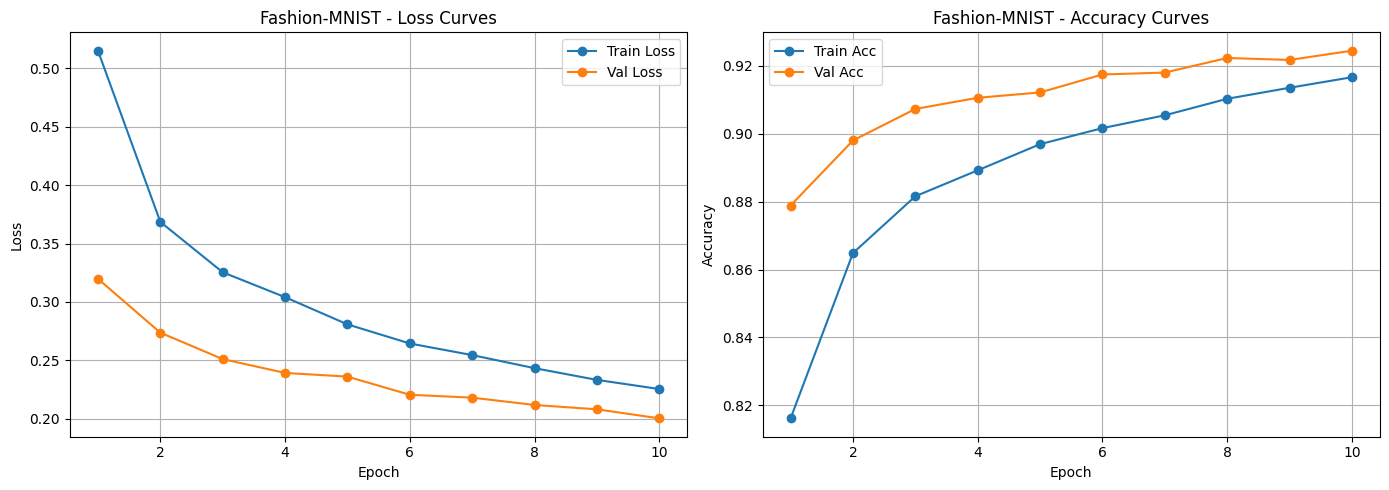

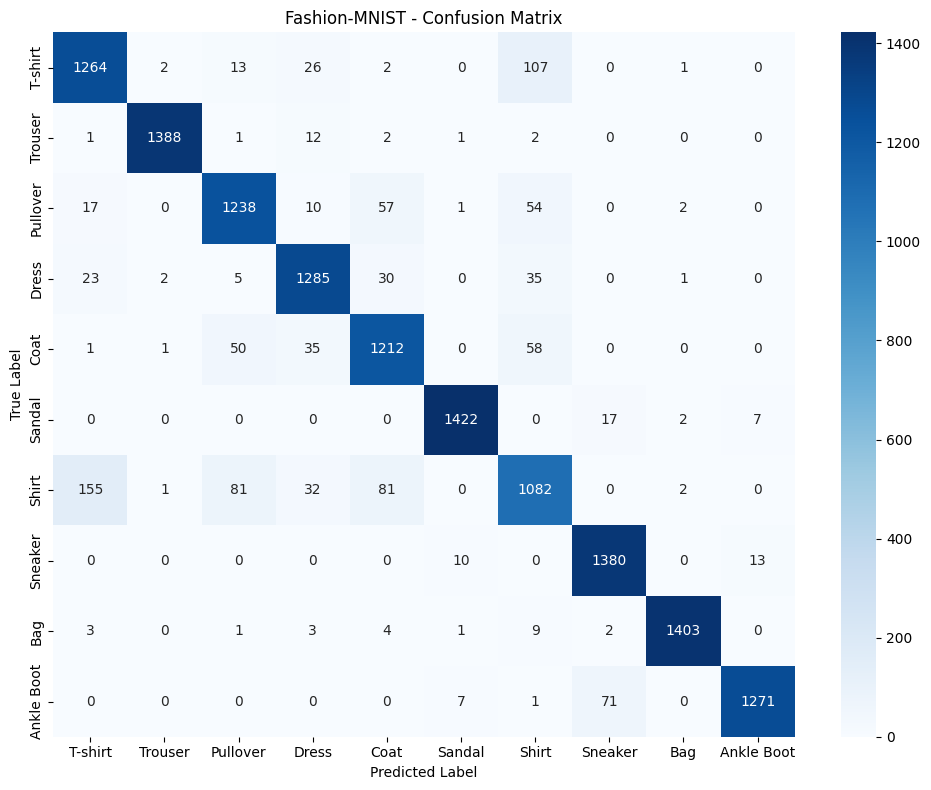

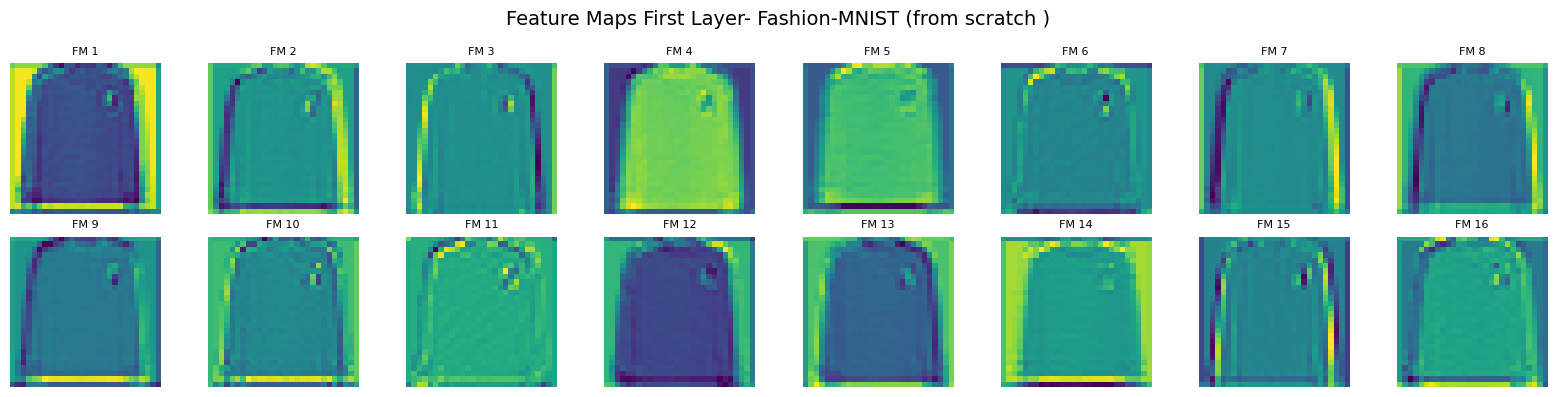

بارگذاری CIFAR-10...
شکل داده: (60000, 3, 32, 32)
  آموزش: 42000 | اعتبارسنجی: 6000 | آزمون: 12000

--- آموزش CIFAR-10 از صفر ---
  Epoch 01/10 (111.1s) | Train Loss: 1.5425 | Train Acc: 45.80% | Val Loss: 1.0854 | Val Acc: 62.00%
  Epoch 02/10 (113.5s) | Train Loss: 1.1598 | Train Acc: 58.80% | Val Loss: 0.9509 | Val Acc: 66.83%
  Epoch 03/10 (133.4s) | Train Loss: 1.0440 | Train Acc: 63.12% | Val Loss: 0.8924 | Val Acc: 69.53%
  Epoch 04/10 (136.0s) | Train Loss: 0.9754 | Train Acc: 65.39% | Val Loss: 0.8358 | Val Acc: 70.90%
  Epoch 05/10 (133.6s) | Train Loss: 0.9201 | Train Acc: 67.34% | Val Loss: 0.8002 | Val Acc: 72.20%
  Epoch 06/10 (134.6s) | Train Loss: 0.8725 | Train Acc: 69.27% | Val Loss: 0.7602 | Val Acc: 74.35%
  Epoch 07/10 (132.7s) | Train Loss: 0.8398 | Train Acc: 70.34% | Val Loss: 0.7576 | Val Acc: 74.08%
  Epoch 08/10 (136.0s) | Train Loss: 0.8015 | Train Acc: 71.63% | Val Loss: 0.7180 | Val Acc: 75.12%
  Epoch 09/10 (114.2s) | Train Loss: 0.7738 | Train Acc: 72.49

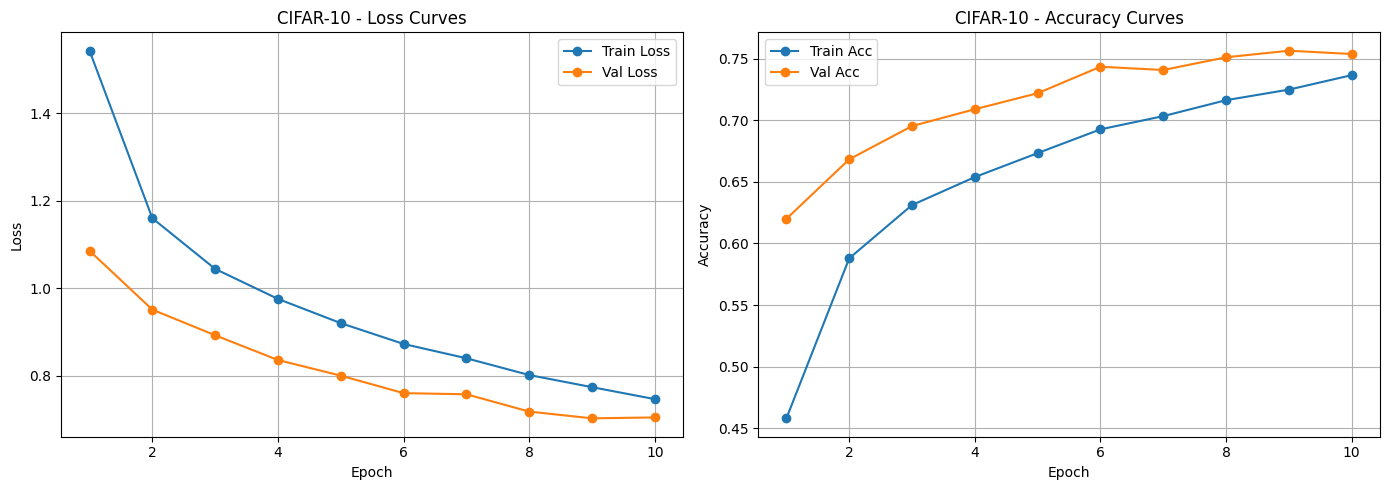

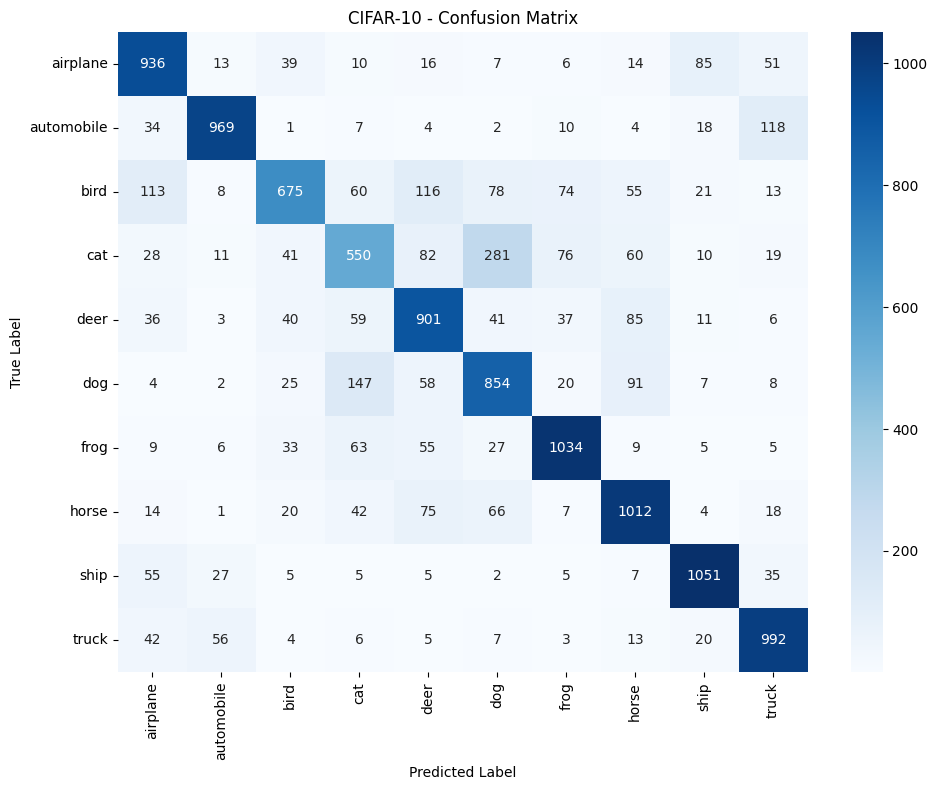

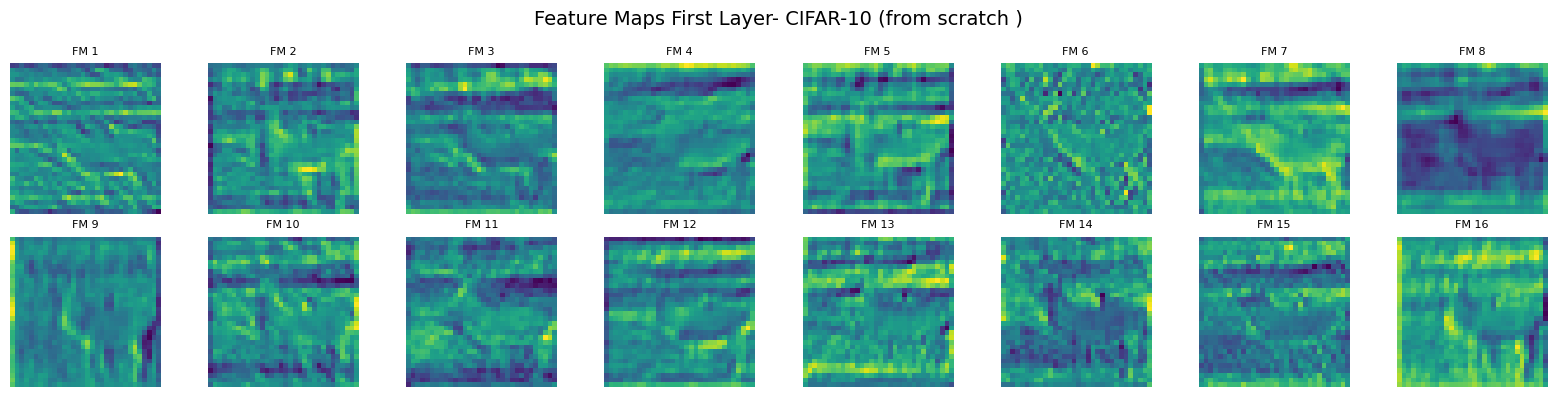

بارگذاری Flower17...
شکل داده: (1360, 3, 32, 32)
  آموزش: 951 | اعتبارسنجی: 136 | آزمون: 273

--- آموزش Flower17 از صفر ---
  Epoch 01/10 (2.7s) | Train Loss: 3.0955 | Train Acc: 14.62% | Val Loss: 2.2269 | Val Acc: 29.41%
  Epoch 02/10 (2.3s) | Train Loss: 2.0502 | Train Acc: 34.93% | Val Loss: 1.7522 | Val Acc: 38.97%
  Epoch 03/10 (2.7s) | Train Loss: 1.6180 | Train Acc: 46.43% | Val Loss: 1.5040 | Val Acc: 45.59%
  Epoch 04/10 (2.5s) | Train Loss: 1.4093 | Train Acc: 54.02% | Val Loss: 1.4153 | Val Acc: 52.94%
  Epoch 05/10 (2.6s) | Train Loss: 1.2133 | Train Acc: 60.16% | Val Loss: 1.3173 | Val Acc: 59.56%
  Epoch 06/10 (2.5s) | Train Loss: 0.9923 | Train Acc: 68.86% | Val Loss: 1.2784 | Val Acc: 57.35%
  Epoch 07/10 (3.0s) | Train Loss: 0.9377 | Train Acc: 71.43% | Val Loss: 1.1973 | Val Acc: 60.29%
  Epoch 08/10 (2.7s) | Train Loss: 0.8132 | Train Acc: 74.67% | Val Loss: 1.1615 | Val Acc: 61.76%
  Epoch 09/10 (2.6s) | Train Loss: 0.7645 | Train Acc: 76.34% | Val Loss: 1.1243 | V

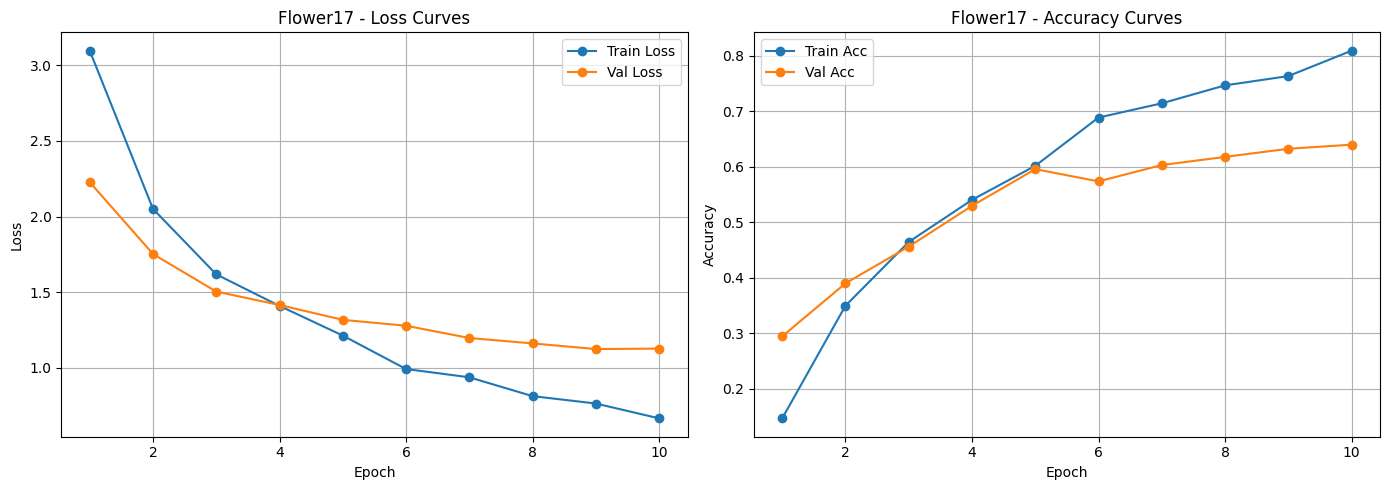

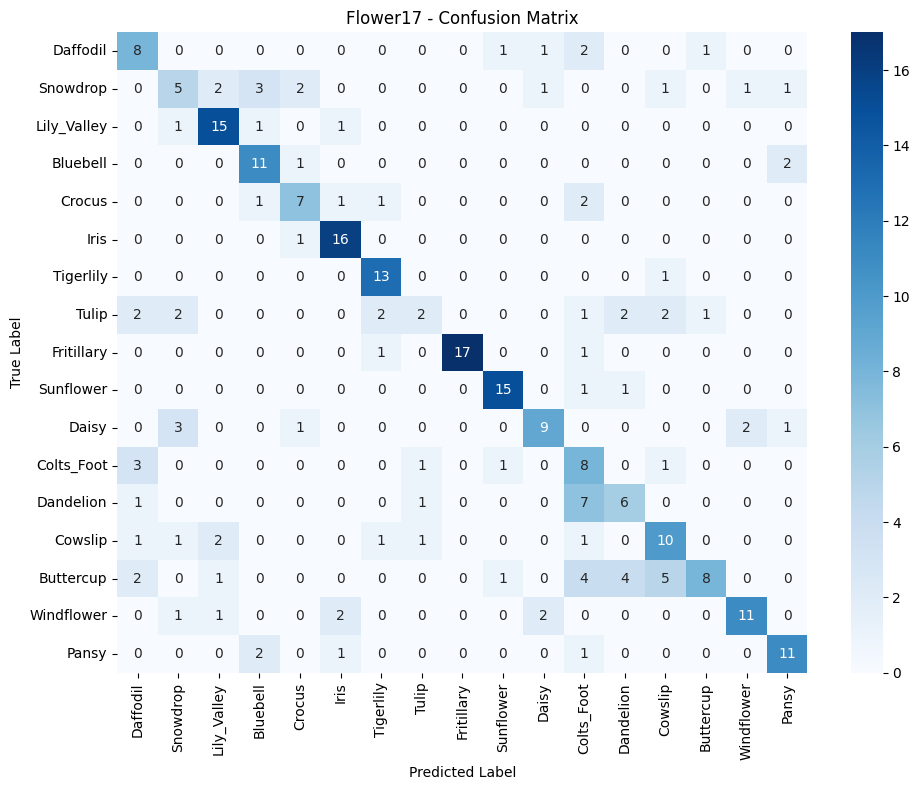

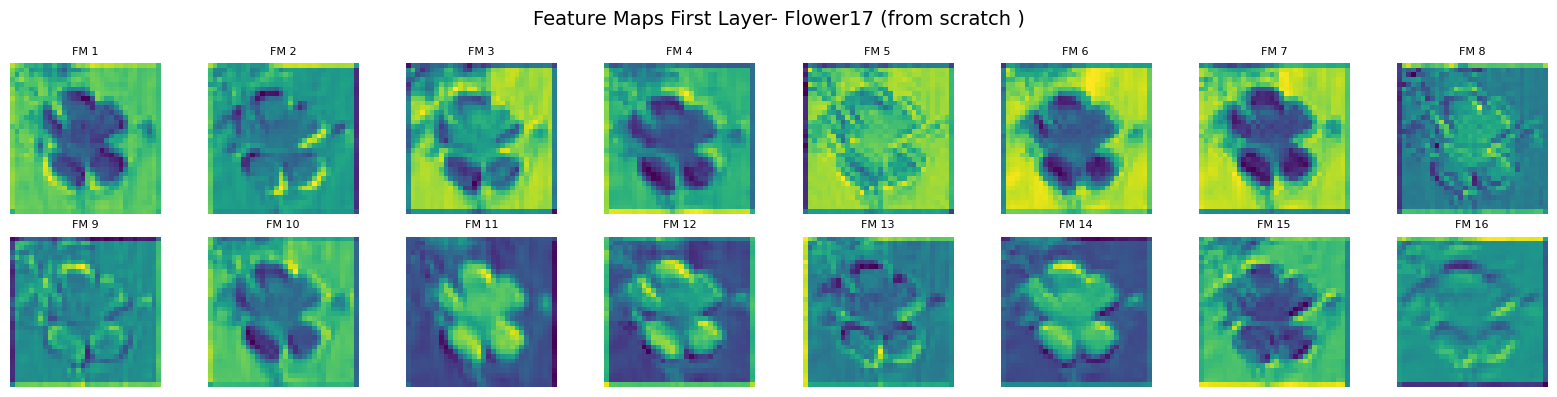


  Results:  CNN (NumPy)
  Fashion-MNIST  |  Accuracy: 92.46%  |  F1: 0.9244
  CIFAR-10       |  Accuracy: 74.78%  |  F1: 0.7444
  Flower17       |  Accuracy: 63.00%  |  F1: 0.6151


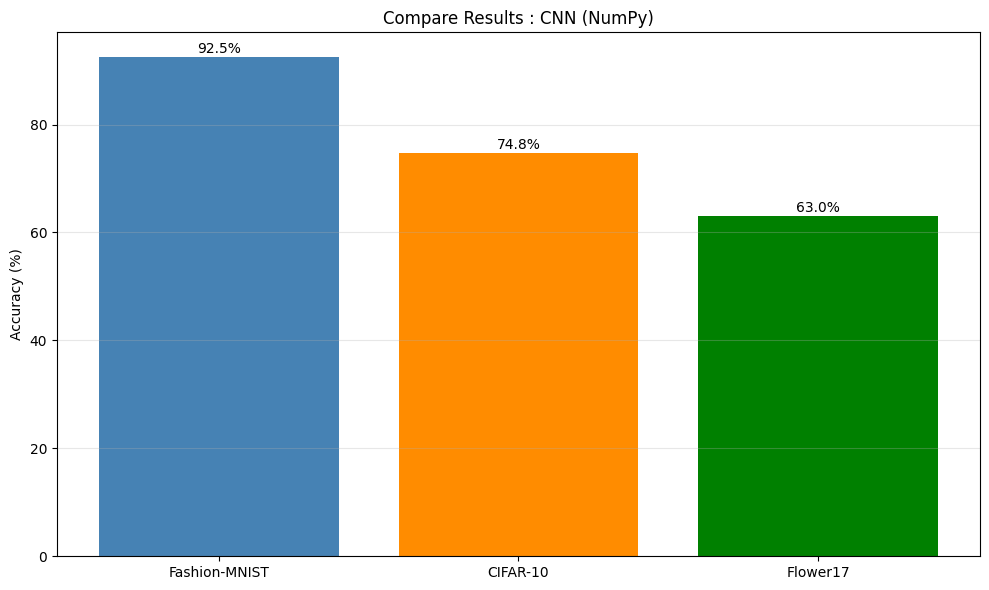


 Building From Scratch FINSIHED


In [1]:
#----------------------------------------------------KASRA ATTAR KASHANI ----------------------------
#---------------------------------------------------Deep Learning - HW3 -------------------------------------
#--------------------------------------------------- TASK 2 -------------------------------------------------
#-------------FashionMnist & Cifar & Flower-----FROM SCRATCH-------------------------------------------------
# Libraries 
import numpy as np
import cupy as cp  
import matplotlib.pyplot as plt
import matplotlib

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)
import seaborn as sns
import os
import struct
import gzip
import urllib.request
import tarfile
import shutil
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
cp.random.seed(42) # Seed for GPU


HYPERPARAMS = {
    'learning_rate': 0.001,
    'batch_size': 64,
    'num_epochs': 10,
    'dropout_rate': 0.5,
    'conv1_filters': 32,
    'conv2_filters': 64,
    'kernel_size': 3,
    'fc1_units': 256,
    'optimizer': 'Adam',
    'activation': 'ReLU',
    'train_ratio': 0.70,
    'val_ratio': 0.10,
    'test_ratio': 0.20,
    'random_seed': 42
}

print('هایپرپارامترها (Similar to PyTorch):')
for k, v in HYPERPARAMS.items():
    print(f'  {k}: {v}')


def relu(x):
    return cp.maximum(0, x)

def relu_backward(dout, x):
    return dout * (x > 0).astype(float)


# ========================================
#  Softmax و Cross-Entropy Loss (GPU)
# ========================================
def softmax(x):
    x_shifted = x - cp.max(x, axis=1, keepdims=True)
    exp_x = cp.exp(x_shifted)
    return exp_x / (cp.sum(exp_x, axis=1, keepdims=True) + 1e-8)

def cross_entropy_loss(probs, labels):
    n = labels.shape[0]
    log_probs = -cp.log(probs[cp.arange(n), labels] + 1e-8)
    return cp.sum(log_probs) / n

def cross_entropy_backward(probs, labels):
    n = labels.shape[0]
    dout = probs.copy()
    dout[cp.arange(n), labels] -= 1
    return dout / n


# ========================================
#  Dropout (GPU)
# ========================================
def dropout_forward(x, rate, training=True):
    if not training:
        return x, None
    mask = (cp.random.rand(*x.shape) > rate) / (1.0 - rate)
    return x * mask, mask

def dropout_backward(dout, mask):
    if mask is None:
        return dout
    return dout * mask

print('توابع پایه تعریف شدند.')


class ConvLayer:
    def __init__(self, in_channels, out_channels, kernel_size, padding=1, stride=1):
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.padding      = padding
        self.stride       = stride
        
        fan_in = in_channels * kernel_size * kernel_size
        std = cp.sqrt(2.0 / fan_in)
        self.W = cp.random.randn(out_channels, in_channels, kernel_size, kernel_size) * std
        self.b = cp.zeros(out_channels)
        
        self.dW = cp.zeros_like(self.W)
        self.db = cp.zeros_like(self.b)
        
        self.mW = cp.zeros_like(self.W); self.vW = cp.zeros_like(self.W)
        self.mb = cp.zeros_like(self.b); self.vb = cp.zeros_like(self.b)
        self.t = 0
        self.cache = None
    
    def _pad(self, x):
        if self.padding > 0:
            return cp.pad(x, ((0,0),(0,0),(self.padding,self.padding),(self.padding,self.padding)),
                          mode='constant')
        return x
    
    def forward(self, x):
        N, C, H, W = x.shape
        F, _, KH, KW = self.W.shape
        
        x_pad = self._pad(x)
        H_out = (H + 2*self.padding - KH) // self.stride + 1
        W_out = (W + 2*self.padding - KW) // self.stride + 1
        
        out = cp.zeros((N, F, H_out, W_out))
        
        for kh in range(KH):
            for kw in range(KW):
                x_slice = x_pad[:, :, kh:kh + H_out*self.stride:self.stride, kw:kw + W_out*self.stride:self.stride]
                out += cp.einsum('nchw,fc->nfhw', x_slice, self.W[:, :, kh, kw])
        
        out += self.b[cp.newaxis, :, cp.newaxis, cp.newaxis]
        self.cache = (x, x_pad)
        return out
    
    def backward(self, dout):
        x, x_pad = self.cache
        N, C, H, W = x.shape
        F, _, KH, KW = self.W.shape
        _, _, H_out, W_out = dout.shape
        
        dx_pad = cp.zeros_like(x_pad)
        self.dW = cp.zeros_like(self.W)
        self.db = cp.sum(dout, axis=(0, 2, 3))
        
        for kh in range(KH):
            for kw in range(KW):
                x_slice = x_pad[:, :, kh:kh + H_out*self.stride:self.stride, kw:kw + W_out*self.stride:self.stride]
                self.dW[:, :, kh, kw] += cp.einsum('nfhw,nchw->fc', dout, x_slice)
                dx_pad[:, :, kh:kh + H_out*self.stride:self.stride, kw:kw + W_out*self.stride:self.stride] += cp.einsum('nfhw,fc->nchw', dout, self.W[:, :, kh, kw])
        
        if self.padding > 0:
            dx = dx_pad[:, :, self.padding:-self.padding, self.padding:-self.padding]
        else:
            dx = dx_pad
        return dx
    
    def update_adam(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for param, grad, m, v in [
            (self.W, self.dW, self.mW, self.vW),
            (self.b, self.db, self.mb, self.vb)
        ]:
            m[:] = beta1 * m + (1 - beta1) * grad
            v[:] = beta2 * v + (1 - beta2) * grad**2
            m_hat = m / (1 - beta1**self.t)
            v_hat = v / (1 - beta2**self.t)
            param -= lr * m_hat / (cp.sqrt(v_hat) + eps)


class BatchNorm2D:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.gamma    = cp.ones(num_features)
        self.beta     = cp.zeros(num_features)
        self.eps      = eps
        self.momentum = momentum
        
        self.running_mean = cp.zeros(num_features)
        self.running_var  = cp.ones(num_features)
        
        self.dgamma = None; self.dbeta = None
        
        self.mg = cp.zeros_like(self.gamma); self.vg = cp.zeros_like(self.gamma)
        self.mb = cp.zeros_like(self.beta);  self.vb = cp.zeros_like(self.beta)
        self.t = 0
        self.cache = None
    
    def forward(self, x, training=True):
        N, C, H, W = x.shape
        
        if training:
            mu  = x.mean(axis=(0, 2, 3), keepdims=True)
            var = x.var(axis=(0, 2, 3), keepdims=True)
            
            x_hat = (x - mu) / cp.sqrt(var + self.eps)
            y = self.gamma[None,:,None,None] * x_hat + self.beta[None,:,None,None]
            
            self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*mu.squeeze()
            self.running_var  = (1-self.momentum)*self.running_var  + self.momentum*var.squeeze()
            
            self.cache = (x, x_hat, mu, var)
        else:
            x_hat = (x - self.running_mean[None,:,None,None]) / cp.sqrt(self.running_var[None,:,None,None] + self.eps)
            y = self.gamma[None,:,None,None] * x_hat + self.beta[None,:,None,None]
        
        return y
    
    def backward(self, dout):
        x, x_hat, mu, var = self.cache
        N, C, H, W = x.shape
        m = N * H * W
        
        self.dgamma = cp.sum(dout * x_hat, axis=(0, 2, 3))
        self.dbeta  = cp.sum(dout, axis=(0, 2, 3))
        
        dx_hat = dout * self.gamma[None,:,None,None]
        std_inv = 1.0 / cp.sqrt(var + self.eps)
        
        dx = (1.0/m) * std_inv * (
            m * dx_hat
            - cp.sum(dx_hat, axis=(0,2,3), keepdims=True)
            - x_hat * cp.sum(dx_hat * x_hat, axis=(0,2,3), keepdims=True)
        )
        return dx
    
    def update_adam(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for param, grad, m, v in [
            (self.gamma, self.dgamma, self.mg, self.vg),
            (self.beta,  self.dbeta,  self.mb, self.vb)
        ]:
            m[:] = beta1 * m + (1 - beta1) * grad
            v[:] = beta2 * v + (1 - beta2) * grad**2
            m_hat = m / (1 - beta1**self.t)
            v_hat = v / (1 - beta2**self.t)
            param -= lr * m_hat / (cp.sqrt(v_hat) + eps)


class BatchNorm1D:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.gamma = cp.ones(num_features)
        self.beta  = cp.zeros(num_features)
        self.eps   = eps
        self.momentum = momentum
        self.running_mean = cp.zeros(num_features)
        self.running_var  = cp.ones(num_features)
        self.dgamma = None; self.dbeta = None
        self.mg = cp.zeros_like(self.gamma); self.vg = cp.zeros_like(self.gamma)
        self.mb = cp.zeros_like(self.beta);  self.vb = cp.zeros_like(self.beta)
        self.t = 0
        self.cache = None
    
    def forward(self, x, training=True):
        if training:
            mu  = x.mean(axis=0)
            var = x.var(axis=0)
            x_hat = (x - mu) / cp.sqrt(var + self.eps)
            y = self.gamma * x_hat + self.beta
            self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*mu
            self.running_var  = (1-self.momentum)*self.running_var  + self.momentum*var
            self.cache = (x, x_hat, mu, var)
        else:
            x_hat = (x - self.running_mean) / cp.sqrt(self.running_var + self.eps)
            y = self.gamma * x_hat + self.beta
        return y
    
    def backward(self, dout):
        x, x_hat, mu, var = self.cache
        N = x.shape[0]
        self.dgamma = cp.sum(dout * x_hat, axis=0)
        self.dbeta  = cp.sum(dout, axis=0)
        dx_hat = dout * self.gamma
        std_inv = 1.0 / cp.sqrt(var + self.eps)
        dx = std_inv/N * (N*dx_hat - cp.sum(dx_hat,0) - x_hat*cp.sum(dx_hat*x_hat,0))
        return dx
    
    def update_adam(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for param, grad, m, v in [
            (self.gamma, self.dgamma, self.mg, self.vg),
            (self.beta,  self.dbeta,  self.mb, self.vb)
        ]:
            m[:] = beta1*m + (1-beta1)*grad
            v[:] = beta2*v + (1-beta2)*grad**2
            param -= lr * (m/(1-beta1**self.t)) / (cp.sqrt(v/(1-beta2**self.t)) + eps)

print('Batch Normalization تعریف شد.')

# ========================================
#  Maxpooling va Fully connected (GPU)
# ========================================
class MaxPool2D:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride    = stride
        self.cache     = None
    
    def forward(self, x):
        N, C, H, W = x.shape
        P, S = self.pool_size, self.stride
        H_out = (H - P) // S + 1
        W_out = (W - P) // S + 1
        
        out  = cp.zeros((N, C, H_out, W_out))
        mask = cp.zeros_like(x) 
        
        for i in range(H_out):
            for j in range(W_out):
                h_s, w_s = i*S, j*S
                patch = x[:, :, h_s:h_s+P, w_s:w_s+P]
                max_val = patch.max(axis=(2, 3), keepdims=True)
                out[:, :, i, j] = max_val.squeeze((2,3))
                mask[:, :, h_s:h_s+P, w_s:w_s+P] += (patch == max_val).astype(float)
        
        self.cache = (x, mask)
        return out
    
    def backward(self, dout):
        x, mask = self.cache
        N, C, H, W = x.shape
        P, S = self.pool_size, self.stride
        H_out, W_out = dout.shape[2], dout.shape[3]
        dx = cp.zeros_like(x)
        
        for i in range(H_out):
            for j in range(W_out):
                h_s, w_s = i*S, j*S
                d = dout[:, :, i, j][:, :, None, None]
                patch_mask = mask[:, :, h_s:h_s+P, w_s:w_s+P]
                norm = patch_mask.sum(axis=(2,3), keepdims=True)
                norm = cp.where(norm == 0, 1, norm)
                dx[:, :, h_s:h_s+P, w_s:w_s+P] += d * patch_mask / norm
        
        return dx


class FullyConnected:
    def __init__(self, in_features, out_features):
        std = cp.sqrt(2.0 / in_features)
        self.W = cp.random.randn(in_features, out_features) * std
        self.b = cp.zeros(out_features)
        self.dW = None; self.db = None
        self.mW = cp.zeros_like(self.W); self.vW = cp.zeros_like(self.W)
        self.mb = cp.zeros_like(self.b);  self.vb = cp.zeros_like(self.b)
        self.t = 0
        self.cache = None
    
    def forward(self, x):
        self.cache = x
        return x @ self.W + self.b
    
    def backward(self, dout):
        x = self.cache
        self.dW = x.T @ dout
        self.db = dout.sum(axis=0)
        return dout @ self.W.T
    
    def update_adam(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for param, grad, m, v in [
            (self.W, self.dW, self.mW, self.vW),
            (self.b, self.db, self.mb, self.vb)
        ]:
            m[:] = beta1*m + (1-beta1)*grad
            v[:] = beta2*v + (1-beta2)*grad**2
            param -= lr * (m/(1-beta1**self.t)) / (cp.sqrt(v/(1-beta2**self.t)) + eps)

print('MaxPool و FullyConnected تعریف شدند.')

# ========================================
#  CNN 
# ========================================

class CNN_FromScratch:
    def __init__(self, in_channels, num_classes, input_size, hp):
        self.hp = hp
        self.dr = hp['dropout_rate']
        
        self.conv1 = ConvLayer(in_channels, hp['conv1_filters'], hp['kernel_size'], padding=1)
        self.bn1   = BatchNorm2D(hp['conv1_filters'])
        self.pool1 = MaxPool2D(pool_size=2, stride=2)
        
        self.conv2 = ConvLayer(hp['conv1_filters'], hp['conv2_filters'], hp['kernel_size'], padding=1)
        self.bn2   = BatchNorm2D(hp['conv2_filters'])
        self.pool2 = MaxPool2D(pool_size=2, stride=2)
        
        flat_size = (input_size // 4) * (input_size // 4) * hp['conv2_filters']
        
        self.fc1   = FullyConnected(flat_size, hp['fc1_units'])
        self.bn_fc = BatchNorm1D(hp['fc1_units'])
        self.fc2   = FullyConnected(hp['fc1_units'], num_classes)
        
        self._cache = {}
        self.feature_maps_conv1 = None
    
    def forward(self, x, training=True):
        c1 = self.conv1.forward(x)
        self.feature_maps_conv1 = c1.copy()
        c1 = self.bn1.forward(c1, training)
        c1 = relu(c1)
        p1 = self.pool1.forward(c1)
        
        c2 = self.conv2.forward(p1)
        c2 = self.bn2.forward(c2, training)
        c2 = relu(c2)
        p2 = self.pool2.forward(c2)
        
        flat = p2.reshape(p2.shape[0], -1)
        
        d1, m1 = dropout_forward(flat, self.dr, training)
        f1 = self.fc1.forward(d1)
        f1 = self.bn_fc.forward(f1, training)
        f1 = relu(f1)
        d2, m2 = dropout_forward(f1, self.dr, training)
        out = self.fc2.forward(d2)
        
        self._cache = {
            'c1_pre_relu': c1, 'p1': p1,
            'c2_pre_relu': c2, 'p2': p2,
            'flat': flat, 'd1': d1, 'm1': m1,
            'f1_pre_relu': f1, 'd2': d2, 'm2': m2
        }
        
        probs = softmax(out)
        return probs
    
    def backward(self, probs, labels):
        c = self._cache
        d_out = cross_entropy_backward(probs, labels)
        
        d_d2 = self.fc2.backward(d_out)
        d_f1 = dropout_backward(d_d2, c['m2'])
        
        d_f1 = relu_backward(d_f1, c['f1_pre_relu'])
        d_f1 = self.bn_fc.backward(d_f1)
        
        d_d1 = self.fc1.backward(d_f1)
        d_flat = dropout_backward(d_d1, c['m1'])
        
        d_p2 = d_flat.reshape(c['p2'].shape)
        
        d_c2 = self.pool2.backward(d_p2)
        d_c2 = relu_backward(d_c2, c['c2_pre_relu'])
        d_c2 = self.bn2.backward(d_c2)
        d_p1 = self.conv2.backward(d_c2)
        
        d_c1 = self.pool1.backward(d_p1)
        d_c1 = relu_backward(d_c1, c['c1_pre_relu'])
        d_c1 = self.bn1.backward(d_c1)
        self.conv1.backward(d_c1)
    
    def update_params(self, lr):
        self.conv1.update_adam(lr)
        self.bn1.update_adam(lr)
        self.conv2.update_adam(lr)
        self.bn2.update_adam(lr)
        self.fc1.update_adam(lr)
        self.bn_fc.update_adam(lr)
        self.fc2.update_adam(lr)
    
    def predict(self, x):
        probs = self.forward(x, training=False)
        return cp.argmax(probs, axis=1)

print('CNN از صفر تعریف شد.')

# ========================================
#  Train Function (Modified to push batches to GPU)
# ========================================

def train_scratch(model, X_train, y_train, X_val, y_val, hp, dataset_name):
    n = X_train.shape[0]
    bs = hp['batch_size']
    lr = hp['learning_rate']
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    print(f'\n--- آموزش {dataset_name} از صفر ---')
    
    for epoch in range(1, hp['num_epochs'] + 1):
        t_start = time.time()
        
        idx = np.random.permutation(n)
        X_sh, y_sh = X_train[idx], y_train[idx]
        
        epoch_loss, epoch_correct = 0.0, 0
        num_batches = n // bs
        
        for i in range(num_batches):
            # Move batch to GPU
            xb = cp.array(X_sh[i*bs:(i+1)*bs])
            yb = cp.array(y_sh[i*bs:(i+1)*bs])
            
            probs = model.forward(xb, training=True)
            loss = cross_entropy_loss(probs, yb)
            model.backward(probs, yb)
            model.update_params(lr)
            
            # Pull metrics back to CPU
            epoch_loss += loss.get()
            epoch_correct += (cp.argmax(probs, axis=1) == yb).sum().get()
        
        train_loss = epoch_loss / num_batches
        train_acc  = float(epoch_correct) / (num_batches * bs)
        
        val_loss, val_acc, _, _ = evaluate_scratch(model, X_val, y_val, bs)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        t_end = time.time()
        print(f'  Epoch {epoch:02d}/{hp["num_epochs"]} ({t_end-t_start:.1f}s) | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')
    
    return history


def evaluate_scratch(model, X, y, batch_size=64):
    n = X.shape[0]
    all_preds, all_labels = [], []
    total_loss = 0.0
    
    for i in range(0, n, batch_size):
        # Move batch to GPU
        xb = cp.array(X[i:i+batch_size])
        yb = cp.array(y[i:i+batch_size])
        
        probs = model.forward(xb, training=False)
        total_loss += (cross_entropy_loss(probs, yb) * len(yb)).get()
        preds = cp.argmax(probs, axis=1)
        
        # Pull predictions back to CPU for evaluation
        all_preds.extend(preds.get())
        all_labels.extend(yb.get())
    
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    avg_loss = float(total_loss) / n
    acc = (all_preds == all_labels).mean()
    
    return avg_loss, acc, all_preds, all_labels


def visualize_feature_maps_scratch(model, x_sample, dataset_name):
    # Push sample to GPU
    xb = cp.array(x_sample[None])
    _ = model.forward(xb, training=False)
    
    # Pull features back to CPU for matplotlib
    fmaps = model.feature_maps_conv1[0].get()  
    num_maps = min(16, fmaps.shape[0])
    
    cols = 8
    rows = (num_maps + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    if rows == 1: axes = [axes]
    
    for i in range(rows):
        for j in range(cols):
            idx = i*cols+j
            ax = axes[i][j]
            if idx < num_maps:
                ax.imshow(fmaps[idx], cmap='viridis')
                ax.set_title(f'FM {idx+1}', fontsize=8)
            ax.axis('off')
    
    plt.suptitle(f'Feature Maps First Layer- {dataset_name} (from scratch )', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'scratch_{dataset_name}_feature_maps.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_and_report(model, X_train, y_train, X_test, y_test, class_names, dataset_name, history):
    # 1. Evaluate on the test set
    avg_loss, acc, all_preds, all_labels = evaluate_scratch(model, X_test, y_test)
    
    # Calculate Macro F1 Score using sklearn
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"\n[{dataset_name}] Test Performance Evaluation:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # 2. Plot Loss and Accuracy Curves
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Curve
    ax1.plot(epochs, history['train_loss'], '-o', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], '-o', label='Val Loss')
    ax1.set_title(f'{dataset_name} - Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy Curve
    ax2.plot(epochs, history['train_acc'], '-o', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], '-o', label='Val Acc')
    ax2.set_title(f'{dataset_name} - Accuracy Curves')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'scratch_{dataset_name}_curves.png', dpi=150)
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{dataset_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'scratch_{dataset_name}_confusion_matrix.png', dpi=150)
    plt.show()
    
    return acc, f1


print('توابع آموزش تعریف شدند.')


def load_fashion_mnist():
    """بارگذاری Fashion-MNIST با NumPy"""
    base = './data/FashionMNIST/raw/'
    files = {
        'train_images': 'train-images-idx3-ubyte',
        'train_labels': 'train-labels-idx1-ubyte',
        'test_images' : 't10k-images-idx3-ubyte',
        'test_labels' : 't10k-labels-idx1-ubyte'
    }
    
    def read_images(path):
        with gzip.open(path+'.gz', 'rb') if os.path.exists(path+'.gz') else open(path, 'rb') as f:
            magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
            return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows, cols)
    
    def read_labels(path):
        with gzip.open(path+'.gz', 'rb') if os.path.exists(path+'.gz') else open(path, 'rb') as f:
            magic, n = struct.unpack('>II', f.read(8))
            return np.frombuffer(f.read(), dtype=np.uint8)
    
    X_train = read_images(base + files['train_images'])
    y_train = read_labels(base + files['train_labels'])
    X_test  = read_images(base + files['test_images'])
    y_test  = read_labels(base + files['test_labels'])
    
    # نرمال‌سازی و reshape
    X_all = np.concatenate([X_train, X_test], axis=0).astype(np.float32) / 255.0
    X_all = (X_all - 0.5) / 0.5
    X_all = X_all[:, None, :, :]  # (N,1,28,28)
    y_all = np.concatenate([y_train, y_test], axis=0)
    return X_all, y_all


def load_cifar10():
    """بارگذاری CIFAR-10 با NumPy"""
    def load_batch(path):
        with open(path, 'rb') as f:
            d = pickle.load(f, encoding='bytes')
        return d[b'data'], np.array(d[b'labels'])
    
    base = './data/cifar-10-batches-py/'
    Xs, ys = [], []
    for i in range(1, 6):
        x, y = load_batch(base + f'data_batch_{i}')
        Xs.append(x); ys.append(y)
    x_test, y_test = load_batch(base + 'test_batch')
    Xs.append(x_test); ys.append(y_test)
    
    X = np.concatenate(Xs).astype(np.float32)
    y = np.concatenate(ys)
    X = X.reshape(-1, 3, 32, 32) / 255.0
    
    mean = np.array([0.4914, 0.4822, 0.4465])[:,None,None]
    std  = np.array([0.2470, 0.2435, 0.2616])[:,None,None]
    X = (X - mean) / std
    return X, y


def load_flower17():
    """بارگذاری Flower17 با NumPy"""
    from PIL import Image
    
    organized_dir = './data/flowers17_organized'
    SIZE = 32  # برای سرعت بیشتر 32x32
    
    FLOWER_CLASSES = [
        'Daffodil','Snowdrop','Lily_Valley','Bluebell','Crocus',
        'Iris','Tigerlily','Tulip','Fritillary','Sunflower',
        'Daisy','Colts_Foot','Dandelion','Cowslip','Buttercup',
        'Windflower','Pansy'
    ]
    
    mean = np.array([0.485,0.456,0.406])[:,None,None]
    std  = np.array([0.229,0.224,0.225])[:,None,None]
    
    Xs, ys = [], []
    for cls_idx, cls_name in enumerate(FLOWER_CLASSES):
        cls_dir = os.path.join(organized_dir, cls_name)
        for img_name in os.listdir(cls_dir):
            img = Image.open(os.path.join(cls_dir, img_name)).convert('RGB')
            img = img.resize((SIZE, SIZE))
            arr = np.array(img).astype(np.float32) / 255.0
            arr = arr.transpose(2,0,1)  # (3,H,W)
            arr = (arr - mean) / std
            Xs.append(arr)
            ys.append(cls_idx)
    
    return np.stack(Xs), np.array(ys)


def split_numpy(X, y, hp):
    """تقسیم داده با NumPy"""
    n = X.shape[0]
    np.random.seed(hp['random_seed'])
    idx = np.random.permutation(n)
    
    tr = int(n * hp['train_ratio'])
    vl = int(n * hp['val_ratio'])
    
    i_tr  = idx[:tr]
    i_val = idx[tr:tr+vl]
    i_te  = idx[tr+vl:]
    
    print(f'  آموزش: {len(i_tr)} | اعتبارسنجی: {len(i_val)} | آزمون: {len(i_te)}')
    return X[i_tr],y[i_tr], X[i_val],y[i_val], X[i_te],y[i_te]


print('توابع بارگذاری داده تعریف شدند.')
# ==================================
#  Fashion-MNIST
# ==================================
FM_CLASSES = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']

print('بارگذاری Fashion-MNIST...')
X_fm, y_fm = load_fashion_mnist()
print(f'شکل داده: {X_fm.shape}')

X_fm_tr,y_fm_tr, X_fm_vl,y_fm_vl, X_fm_te,y_fm_te = split_numpy(X_fm, y_fm, HYPERPARAMS)

model_fm = CNN_FromScratch(
    in_channels=1, num_classes=10,
    input_size=28, hp=HYPERPARAMS
)

history_fm = train_scratch(model_fm, X_fm_tr, y_fm_tr, X_fm_vl, y_fm_vl, HYPERPARAMS, 'Fashion-MNIST')
fm_acc_s, fm_f1_s = plot_and_report(
    model_fm, X_fm_tr, y_fm_tr, X_fm_te, y_fm_te,
    FM_CLASSES, 'Fashion-MNIST', history_fm
)
visualize_feature_maps_scratch(model_fm, X_fm_te[0], 'Fashion-MNIST')

# ==================================
#  Cifar
# ==================================

CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print('بارگذاری CIFAR-10...')
X_cf, y_cf = load_cifar10()
print(f'شکل داده: {X_cf.shape}')

X_cf_tr,y_cf_tr, X_cf_vl,y_cf_vl, X_cf_te,y_cf_te = split_numpy(X_cf, y_cf, HYPERPARAMS)

model_cf = CNN_FromScratch(
    in_channels=3, num_classes=10,
    input_size=32, hp=HYPERPARAMS
)

history_cf = train_scratch(model_cf, X_cf_tr, y_cf_tr, X_cf_vl, y_cf_vl, HYPERPARAMS, 'CIFAR-10')
cf_acc_s, cf_f1_s = plot_and_report(
    model_cf, X_cf_tr, y_cf_tr, X_cf_te, y_cf_te,
    CIFAR_CLASSES, 'CIFAR-10', history_cf
)
visualize_feature_maps_scratch(model_cf, X_cf_te[0], 'CIFAR-10')


# ==================================
#  Flower
# ==================================

FLOWER_CLASSES = [
    'Daffodil','Snowdrop','Lily_Valley','Bluebell','Crocus',
    'Iris','Tigerlily','Tulip','Fritillary','Sunflower',
    'Daisy','Colts_Foot','Dandelion','Cowslip','Buttercup',
    'Windflower','Pansy'
]

print('بارگذاری Flower17...')
X_fl, y_fl = load_flower17()
print(f'شکل داده: {X_fl.shape}')

X_fl_tr,y_fl_tr, X_fl_vl,y_fl_vl, X_fl_te,y_fl_te = split_numpy(X_fl, y_fl, HYPERPARAMS)

model_fl = CNN_FromScratch(
    in_channels=3, num_classes=17,
    input_size=32, hp=HYPERPARAMS
)

history_fl = train_scratch(model_fl, X_fl_tr, y_fl_tr, X_fl_vl, y_fl_vl, HYPERPARAMS, 'Flower17')
fl_acc_s, fl_f1_s = plot_and_report(
    model_fl, X_fl_tr, y_fl_tr, X_fl_te, y_fl_te,
    FLOWER_CLASSES, 'Flower17', history_fl
)
visualize_feature_maps_scratch(model_fl, X_fl_te[0], 'Flower17')

# --------- جمع بندی ---------------
print('\n' + '='*60)
print('  Results:  CNN (NumPy)')
print('='*60)
print(f'  Fashion-MNIST  |  Accuracy: {fm_acc_s*100:.2f}%  |  F1: {fm_f1_s:.4f}')
print(f'  CIFAR-10       |  Accuracy: {cf_acc_s*100:.2f}%  |  F1: {cf_f1_s:.4f}')
print(f'  Flower17       |  Accuracy: {fl_acc_s*100:.2f}%  |  F1: {fl_f1_s:.4f}')
print('='*60)

# نمودار مقایسه
ds_names = ['Fashion-MNIST', 'CIFAR-10', 'Flower17']
accs = [fm_acc_s*100, cf_acc_s*100, fl_acc_s*100]
f1s  = [fm_f1_s, cf_f1_s, fl_f1_s]

x = np.arange(len(ds_names))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, accs, color=['steelblue','darkorange','green'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Compare Results : CNN (NumPy)')
ax.set_xticks(x); ax.set_xticklabels(ds_names)
for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,3), textcoords='offset points', ha='center')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('scratch_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Building From Scratch FINSIHED')

Using device: cuda
  GPU: NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM: 4.0 GB
هایپرپارامترها:
  learning_rate: 0.001
  batch_size: 64
  num_epochs: 10
  dropout_rate: 0.5
  conv1_filters: 32
  conv2_filters: 64
  kernel_size: 3
  fc1_units: 256
  optimizer: Adam
  activation: ReLU
  train_ratio: 0.7
  val_ratio: 0.1
  test_ratio: 0.2
  random_seed: 42
معماری CNN تعریف شد.
معماری CNN_Flower تعریف شد.
توابع کمکی تعریف شدند.
بارگذاری Fashion-MNIST از local...
Fashion-MNIST - تعداد کل: 70000
  آموزش: 49000 | اعتبارسنجی: 7000 | آزمون: 14000


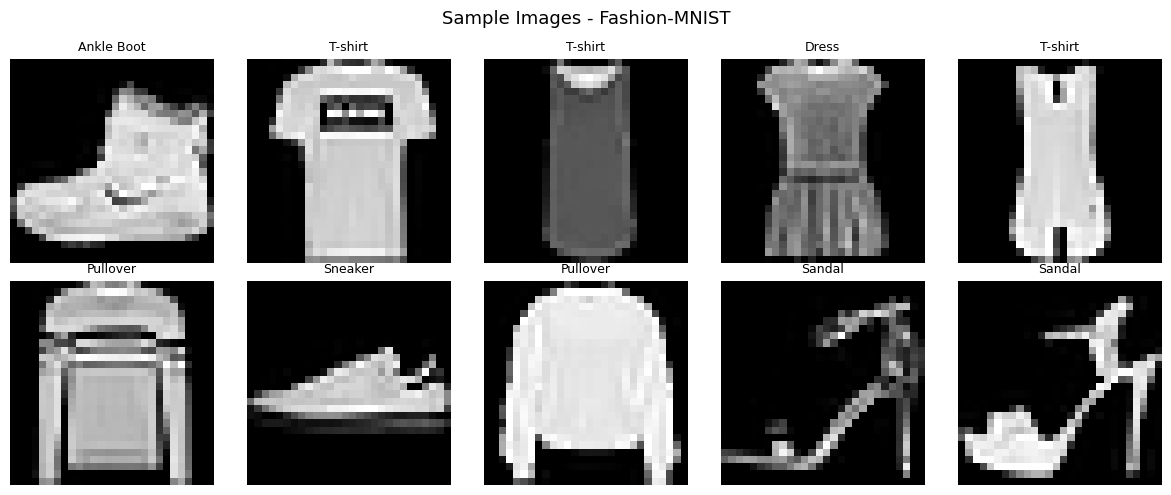

Fashion-MNIST آماده شد.
معماری مدل Fashion-MNIST:
CNN_PyTorch(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=256, bias=True)
  (bn_fc): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


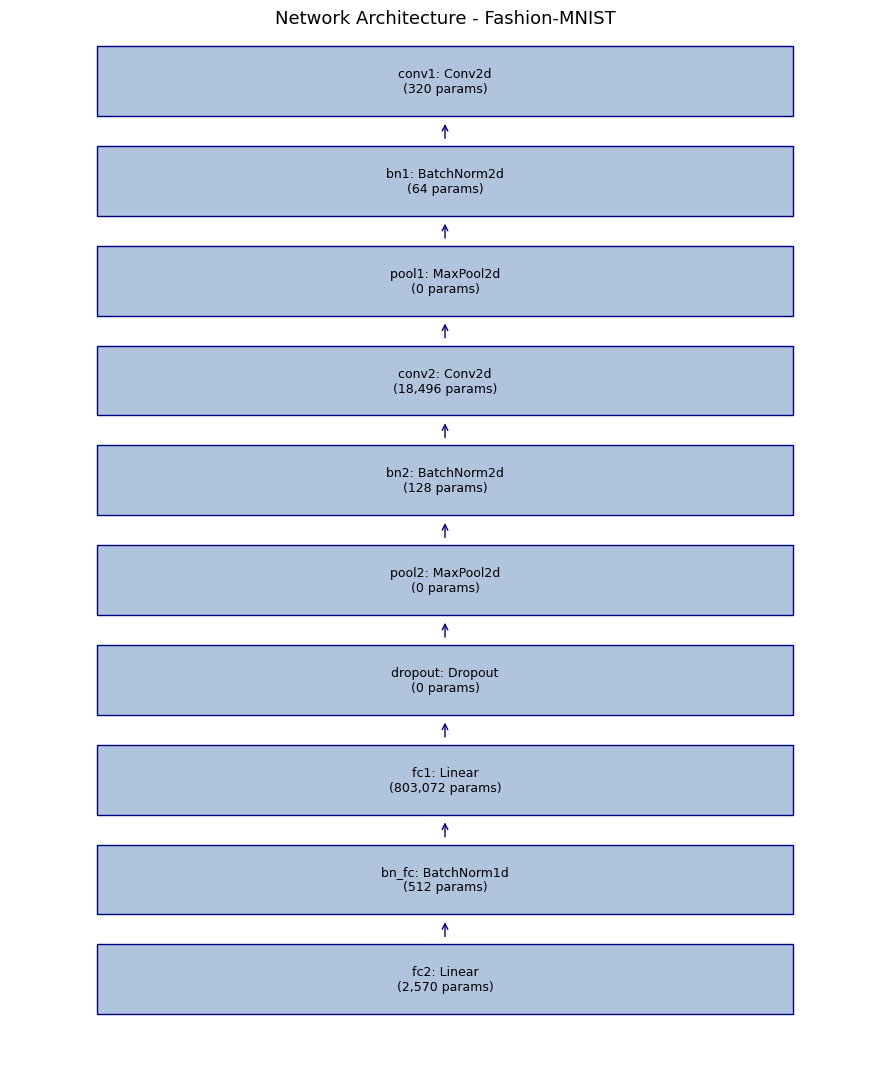


تعداد کل پارامترها: 825,162

--- آموزش Fashion-MNIST ---
  Epoch 01/10 | Train Loss: 0.4581 | Train Acc: 83.78% | Val Loss: 0.2862 | Val Acc: 89.50%
  Epoch 02/10 | Train Loss: 0.3407 | Train Acc: 87.52% | Val Loss: 0.2562 | Val Acc: 90.54%
  Epoch 03/10 | Train Loss: 0.3061 | Train Acc: 88.71% | Val Loss: 0.2433 | Val Acc: 91.01%
  Epoch 04/10 | Train Loss: 0.2824 | Train Acc: 89.59% | Val Loss: 0.2377 | Val Acc: 91.00%
  Epoch 05/10 | Train Loss: 0.2679 | Train Acc: 90.14% | Val Loss: 0.2249 | Val Acc: 91.53%
  Epoch 06/10 | Train Loss: 0.2532 | Train Acc: 90.72% | Val Loss: 0.2267 | Val Acc: 91.13%
  Epoch 07/10 | Train Loss: 0.2406 | Train Acc: 91.01% | Val Loss: 0.2072 | Val Acc: 92.14%
  Epoch 08/10 | Train Loss: 0.2164 | Train Acc: 91.96% | Val Loss: 0.2008 | Val Acc: 92.31%
  Epoch 09/10 | Train Loss: 0.2076 | Train Acc: 92.26% | Val Loss: 0.1980 | Val Acc: 92.61%
  Epoch 10/10 | Train Loss: 0.1996 | Train Acc: 92.55% | Val Loss: 0.1951 | Val Acc: 92.81%


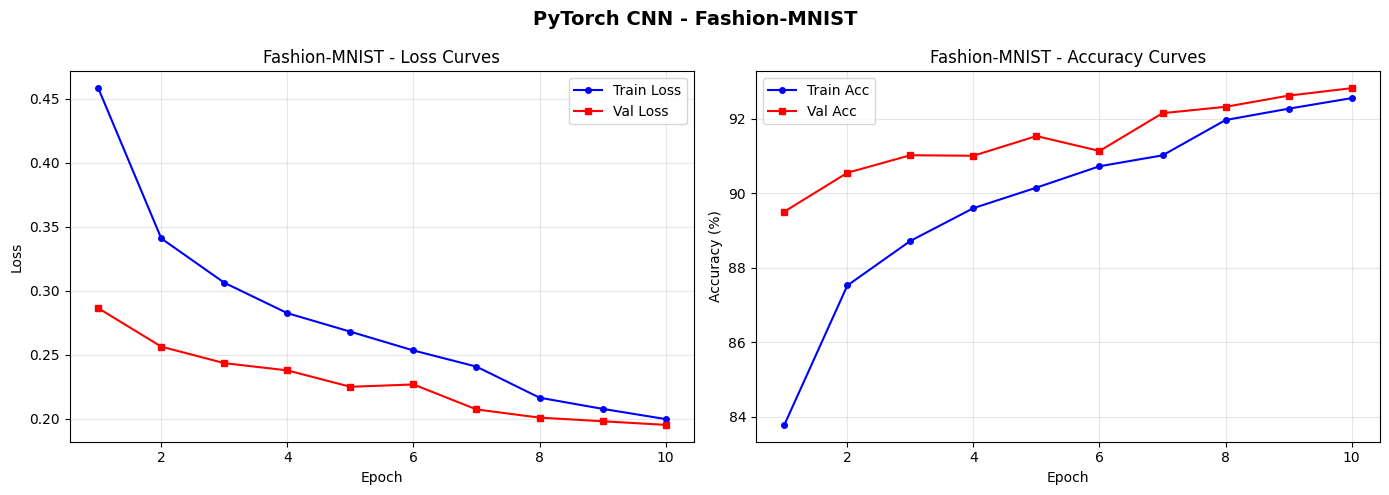


====== Fashion-MNIST - Train ======
  Accuracy:            95.58%
  F1-score (Macro):    0.9556
  F1-score (Weighted): 0.9556

  گزارش کامل:
              precision    recall  f1-score   support

     T-shirt     0.9223    0.9217    0.9220      4868
     Trouser     0.9982    0.9955    0.9968      4927
    Pullover     0.9317    0.9216    0.9266      4896
       Dress     0.9390    0.9724    0.9554      4894
        Coat     0.9176    0.9383    0.9278      4912
      Sandal     0.9968    0.9962    0.9965      4951
       Shirt     0.8854    0.8483    0.8665      4937
     Sneaker     0.9738    0.9922    0.9829      4866
         Bag     0.9988    0.9963    0.9975      4896
  Ankle Boot     0.9933    0.9757    0.9844      4853

    accuracy                         0.9558     49000
   macro avg     0.9557    0.9558    0.9556     49000
weighted avg     0.9557    0.9558    0.9556     49000



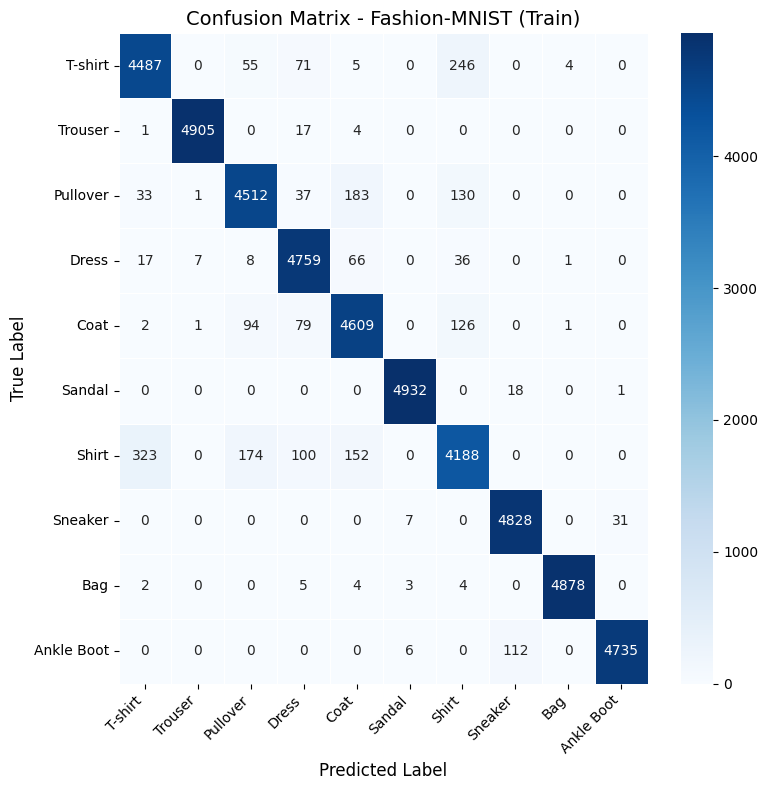


====== Fashion-MNIST - Test ======
  Accuracy:            92.82%
  F1-score (Macro):    0.9276
  F1-score (Weighted): 0.9280

  گزارش کامل:
              precision    recall  f1-score   support

     T-shirt     0.8914    0.8743    0.8828      1408
     Trouser     0.9978    0.9883    0.9930      1371
    Pullover     0.8880    0.8923    0.8901      1430
       Dress     0.9085    0.9558    0.9315      1402
        Coat     0.8804    0.8867    0.8835      1403
      Sandal     0.9839    0.9825    0.9832      1368
       Shirt     0.8042    0.7737    0.7887      1348
     Sneaker     0.9529    0.9766    0.9646      1408
         Bag     0.9895    0.9888    0.9892      1430
  Ankle Boot     0.9800    0.9588    0.9693      1432

    accuracy                         0.9282     14000
   macro avg     0.9276    0.9278    0.9276     14000
weighted avg     0.9280    0.9282    0.9280     14000



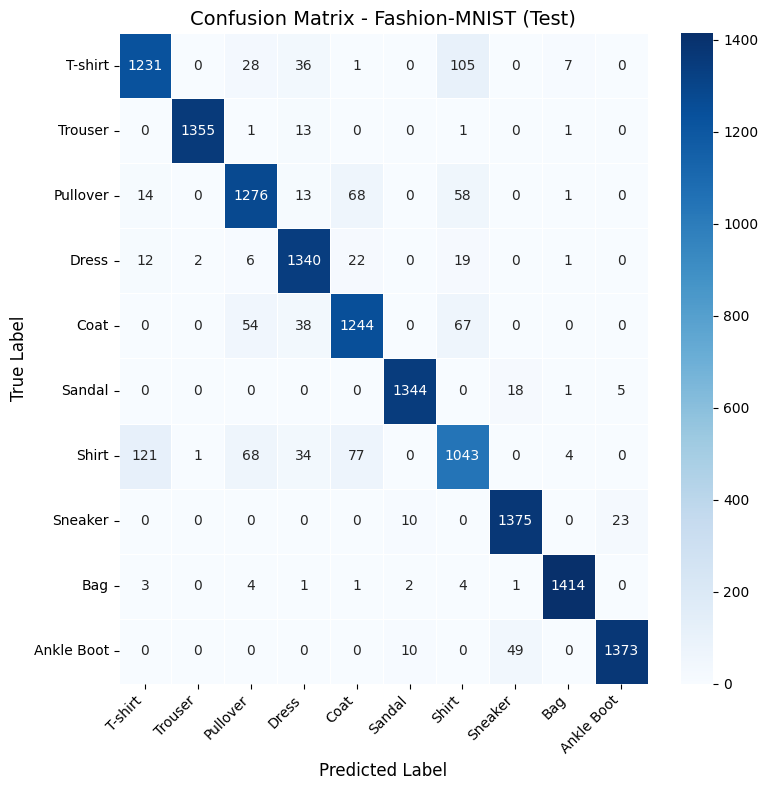

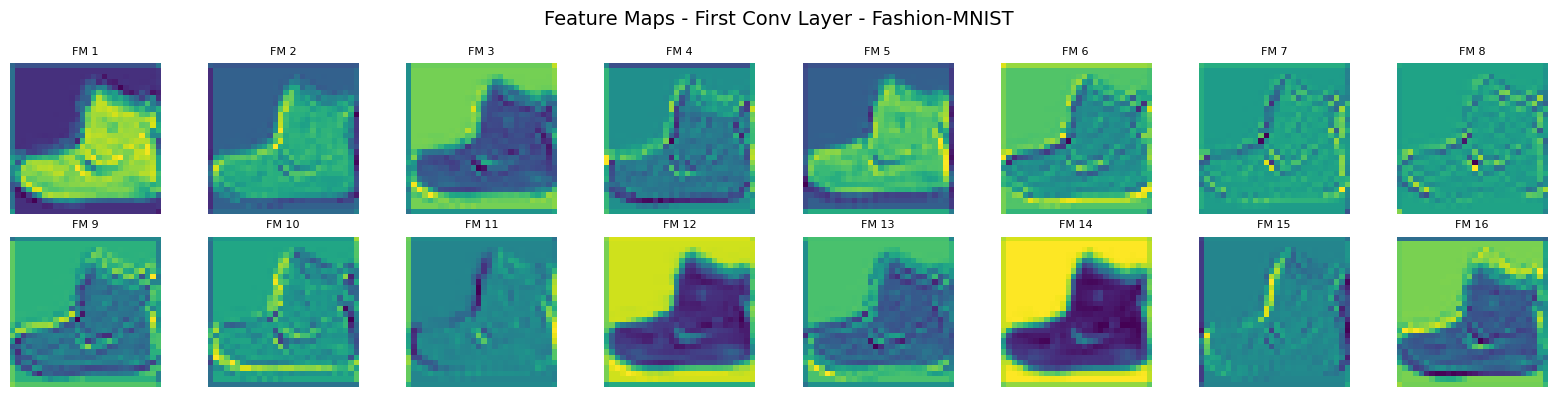

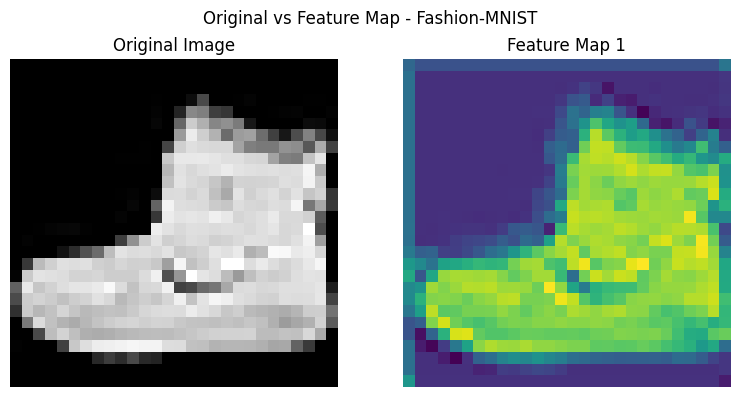

✓ Fashion-MNIST model saved → best_model_fashion_mnist.pth
✓ Loaded model — saved test acc: 92.82%
بارگذاری CIFAR-10 از local...
CIFAR-10 - تعداد کل: 60000
  آموزش: 42000 | اعتبارسنجی: 6000 | آزمون: 12000


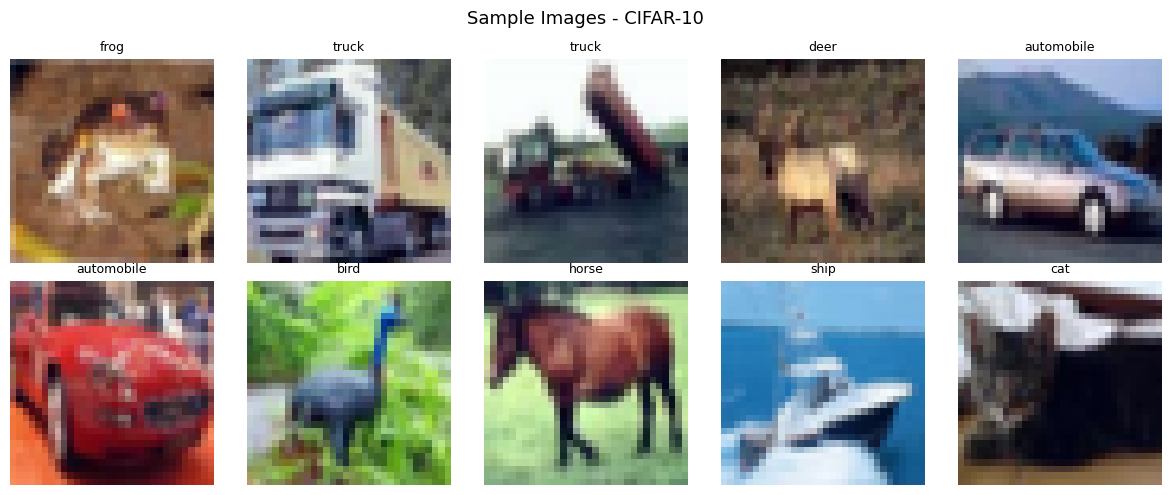

CIFAR-10 آماده شد.
تعداد کل پارامترها: 1,071,498


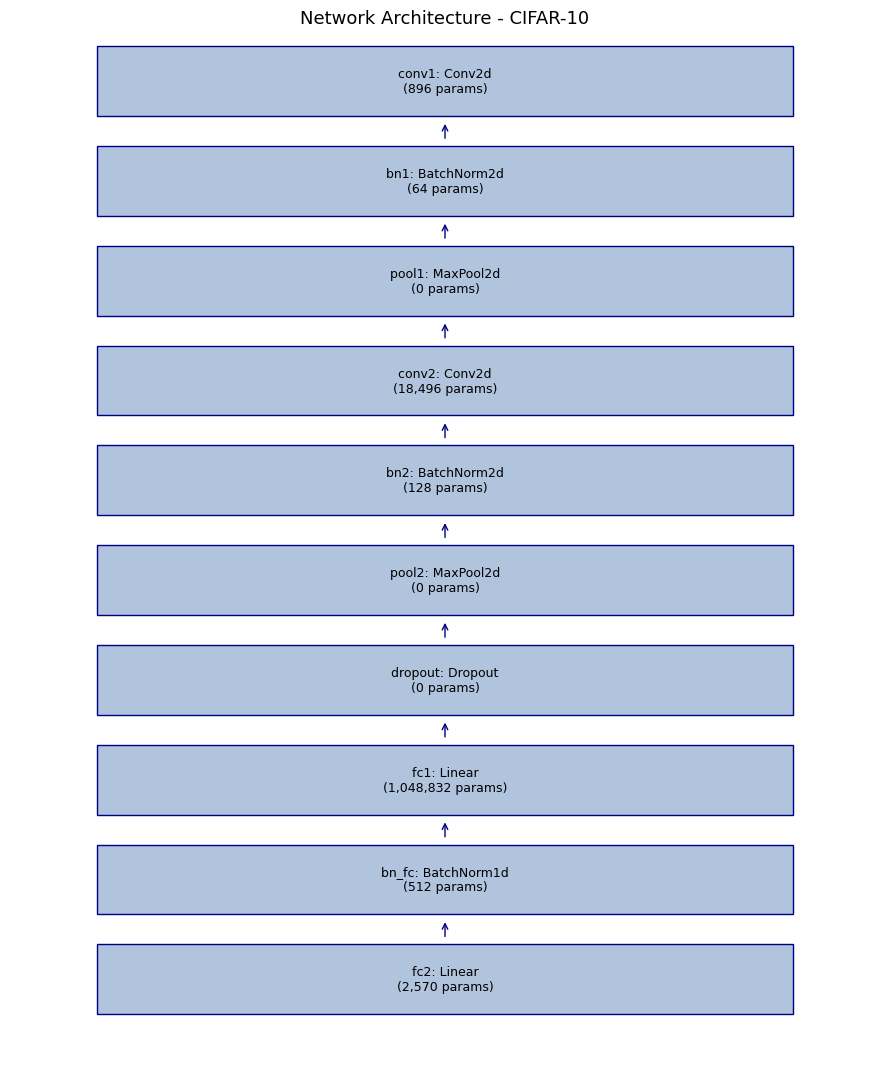


--- آموزش CIFAR-10 ---
  Epoch 01/10 | Train Loss: 1.3523 | Train Acc: 51.59% | Val Loss: 1.0704 | Val Acc: 62.62%
  Epoch 02/10 | Train Loss: 1.1023 | Train Acc: 60.64% | Val Loss: 0.9442 | Val Acc: 65.97%
  Epoch 03/10 | Train Loss: 1.0078 | Train Acc: 64.30% | Val Loss: 0.8428 | Val Acc: 70.32%
  Epoch 04/10 | Train Loss: 0.9438 | Train Acc: 66.61% | Val Loss: 0.8132 | Val Acc: 70.98%
  Epoch 05/10 | Train Loss: 0.8912 | Train Acc: 68.47% | Val Loss: 0.7840 | Val Acc: 72.42%
  Epoch 06/10 | Train Loss: 0.8496 | Train Acc: 70.22% | Val Loss: 0.7307 | Val Acc: 74.05%
  Epoch 07/10 | Train Loss: 0.8161 | Train Acc: 71.37% | Val Loss: 0.7092 | Val Acc: 75.17%
  Epoch 08/10 | Train Loss: 0.7501 | Train Acc: 73.71% | Val Loss: 0.6769 | Val Acc: 75.40%
  Epoch 09/10 | Train Loss: 0.7208 | Train Acc: 74.49% | Val Loss: 0.6653 | Val Acc: 76.32%
  Epoch 10/10 | Train Loss: 0.6992 | Train Acc: 75.26% | Val Loss: 0.6599 | Val Acc: 76.45%


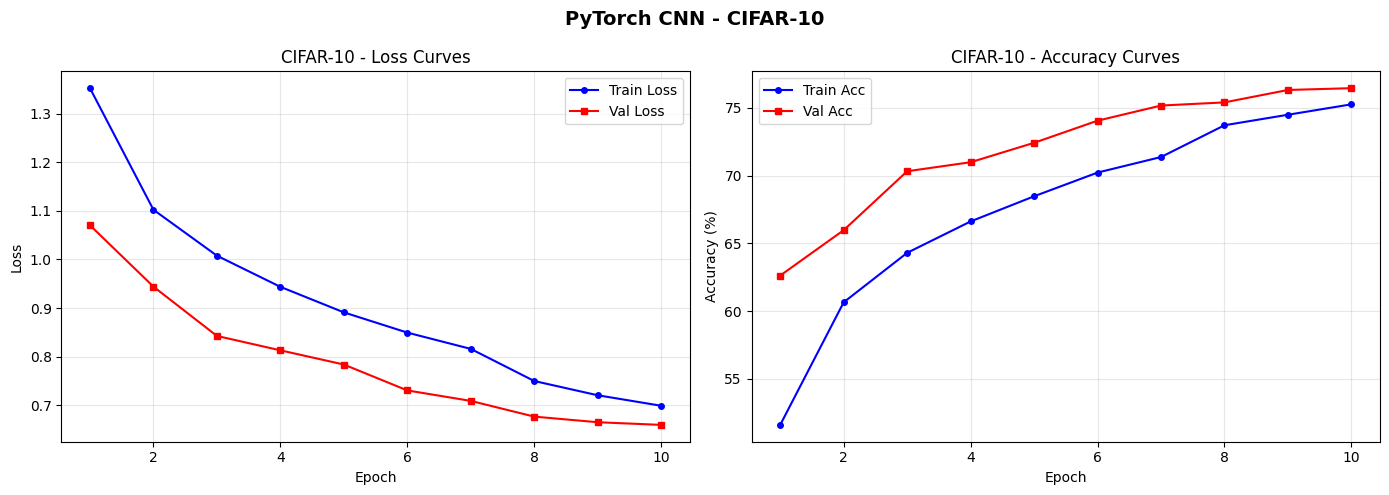


====== CIFAR-10 - Train ======
  Accuracy:            85.15%
  F1-score (Macro):    0.8512
  F1-score (Weighted): 0.8511

  گزارش کامل:
              precision    recall  f1-score   support

    airplane     0.8749    0.8674    0.8711      4247
  automobile     0.9290    0.9479    0.9383      4263
        bird     0.8500    0.7157    0.7771      4179
         cat     0.7107    0.7197    0.7152      4256
        deer     0.8085    0.8302    0.8192      4200
         dog     0.7472    0.7856    0.7659      4175
        frog     0.8605    0.9120    0.8855      4180
       horse     0.9259    0.8711    0.8977      4175
        ship     0.8931    0.9557    0.9233      4195
       truck     0.9264    0.9107    0.9184      4130

    accuracy                         0.8515     42000
   macro avg     0.8526    0.8516    0.8512     42000
weighted avg     0.8524    0.8515    0.8511     42000



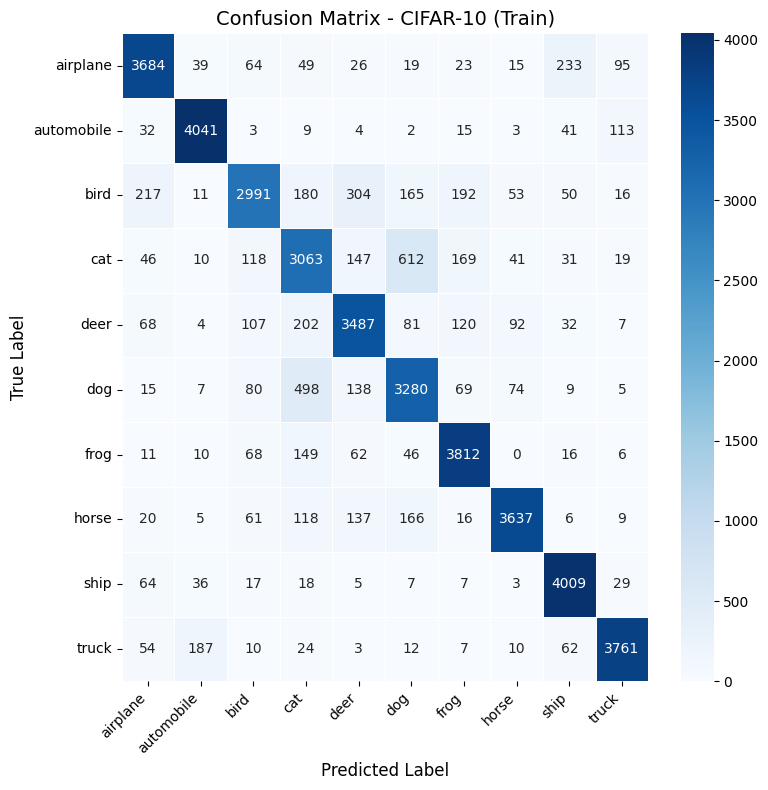


====== CIFAR-10 - Test ======
  Accuracy:            75.94%
  F1-score (Macro):    0.7582
  F1-score (Weighted): 0.7584

  گزارش کامل:
              precision    recall  f1-score   support

    airplane     0.7697    0.7777    0.7737      1156
  automobile     0.8428    0.8855    0.8636      1162
        bird     0.7451    0.5914    0.6594      1231
         cat     0.5683    0.5799    0.5741      1176
        deer     0.7008    0.7340    0.7170      1184
         dog     0.6493    0.6838    0.6661      1205
        frog     0.7937    0.8551    0.8233      1215
       horse     0.8542    0.7792    0.8150      1241
        ship     0.8152    0.8822    0.8473      1205
       truck     0.8585    0.8269    0.8424      1225

    accuracy                         0.7594     12000
   macro avg     0.7598    0.7596    0.7582     12000
weighted avg     0.7604    0.7594    0.7584     12000



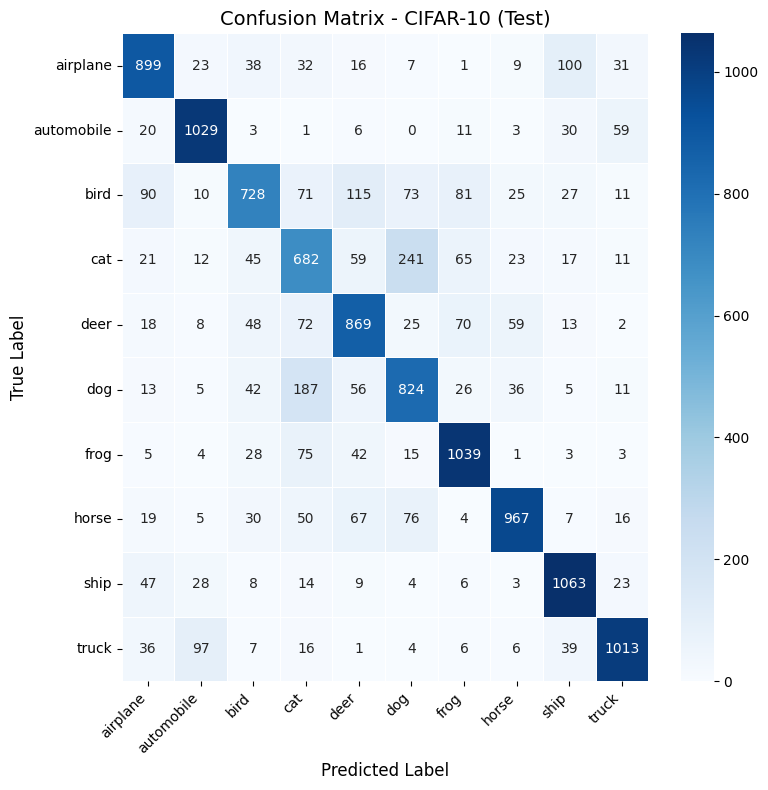

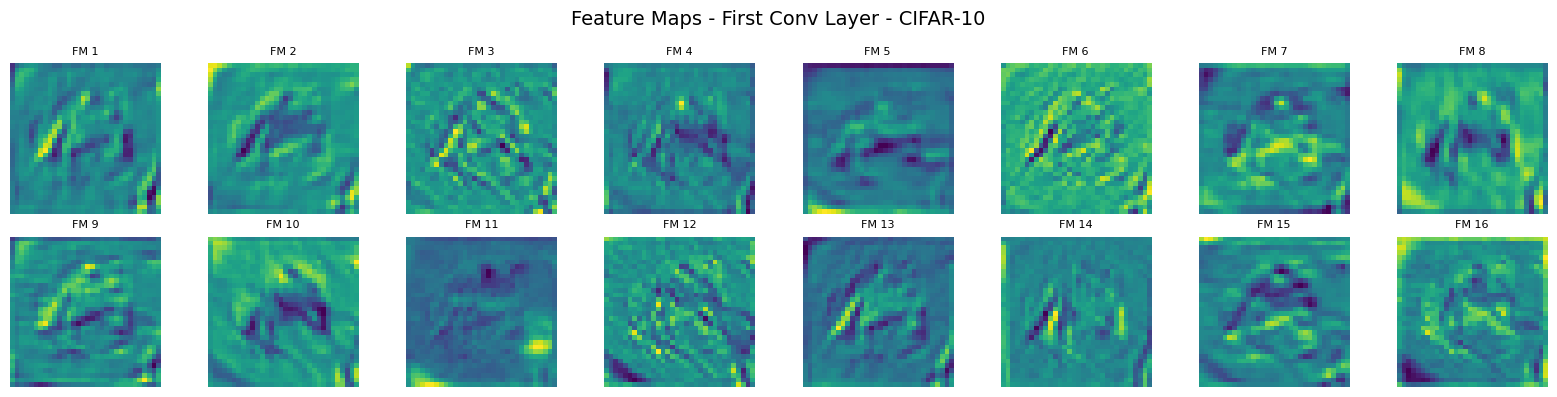

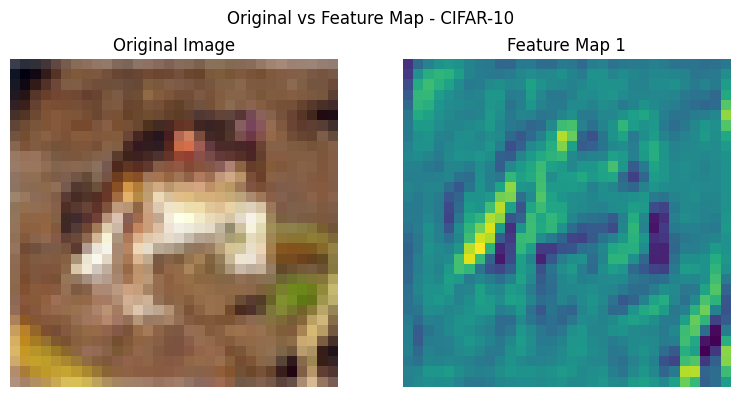

✓ CIFAR-10 model saved → best_model_cifar10.pth
✓ Loaded model — saved test acc: 75.94%
بارگذاری Flower17 از local...
Flower17 - تعداد کل: 1360
کلاس‌های پیدا شده: ['Bluebell', 'Buttercup', 'Colts_Foot', 'Cowslip', 'Crocus', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'Lily_Valley', 'Pansy', 'Snowdrop', 'Sunflower', 'Tigerlily', 'Tulip', 'Windflower']
  آموزش: 951 | اعتبارسنجی: 136 | آزمون: 273


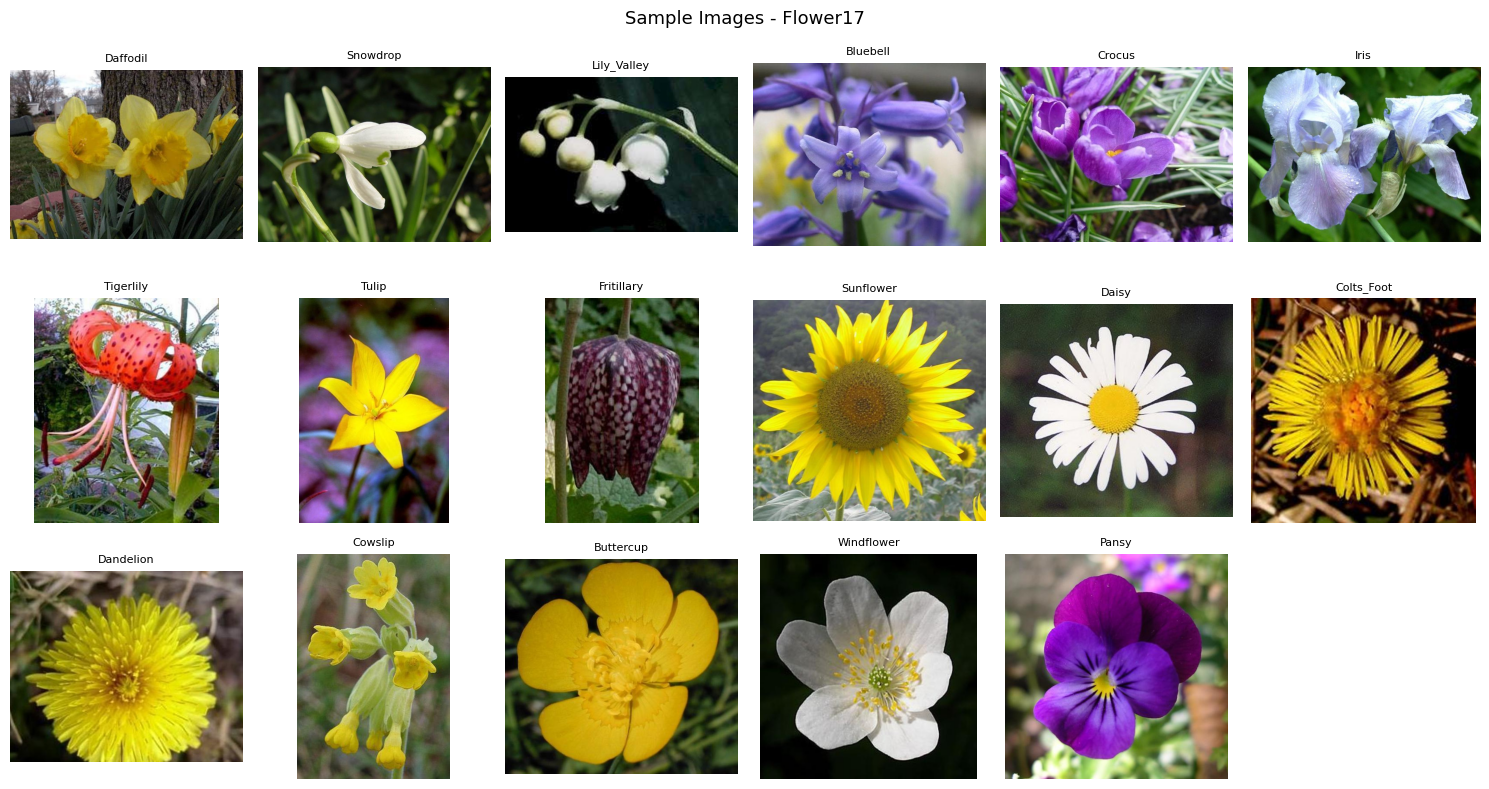

Flower17 آماده شد.
تعداد کل پارامترها (Flower17): 1,073,297


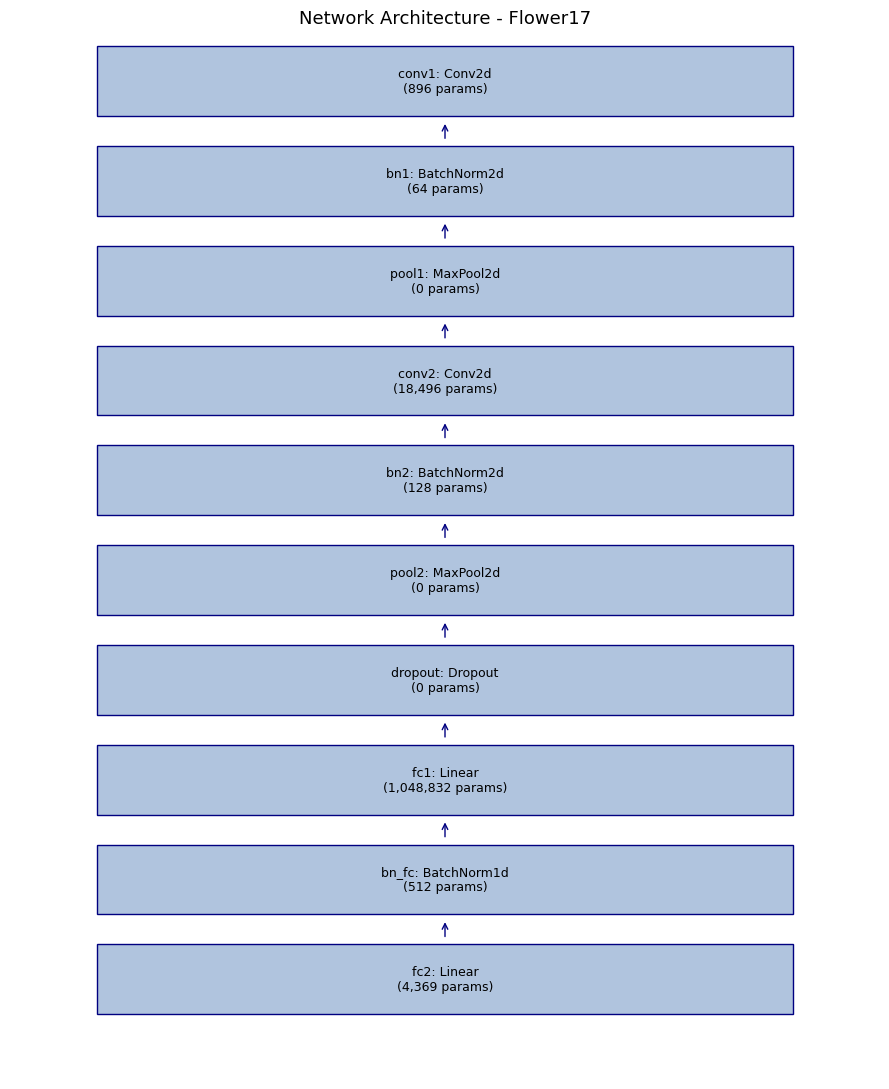


--- آموزش Flower17 ---
  Epoch 01/10 | Train Loss: 2.3417 | Train Acc: 26.81% | Val Loss: 2.1797 | Val Acc: 36.03%
  Epoch 02/10 | Train Loss: 1.6504 | Train Acc: 52.37% | Val Loss: 1.9061 | Val Acc: 39.71%
  Epoch 03/10 | Train Loss: 1.2957 | Train Acc: 64.25% | Val Loss: 1.7361 | Val Acc: 46.32%
  Epoch 04/10 | Train Loss: 1.1013 | Train Acc: 72.34% | Val Loss: 1.6533 | Val Acc: 50.00%
  Epoch 05/10 | Train Loss: 0.9033 | Train Acc: 77.39% | Val Loss: 1.5624 | Val Acc: 55.88%
  Epoch 06/10 | Train Loss: 0.7707 | Train Acc: 82.86% | Val Loss: 1.5089 | Val Acc: 55.15%
  Epoch 07/10 | Train Loss: 0.6525 | Train Acc: 84.86% | Val Loss: 1.4753 | Val Acc: 55.88%
  Epoch 08/10 | Train Loss: 0.5552 | Train Acc: 87.80% | Val Loss: 1.4314 | Val Acc: 57.35%
  Epoch 09/10 | Train Loss: 0.5194 | Train Acc: 89.17% | Val Loss: 1.4146 | Val Acc: 58.82%
  Epoch 10/10 | Train Loss: 0.4714 | Train Acc: 92.22% | Val Loss: 1.4354 | Val Acc: 55.88%


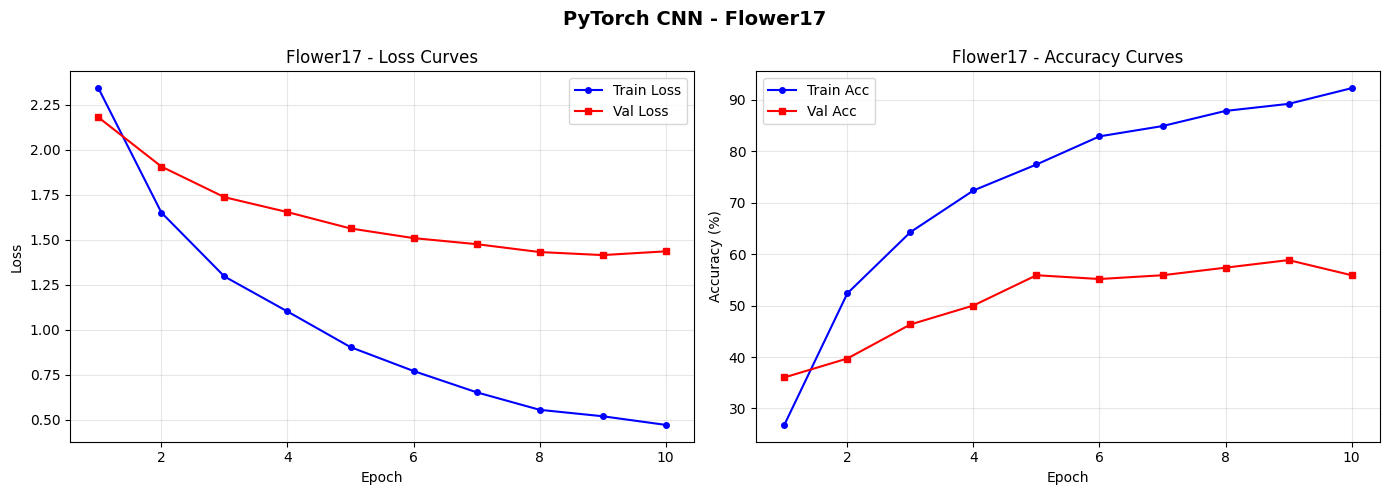


====== Flower17 - Train ======
  Accuracy:            98.63%
  F1-score (Macro):    0.9860
  F1-score (Weighted): 0.9863

  گزارش کامل:
              precision    recall  f1-score   support

    Daffodil     0.9833    1.0000    0.9916        59
    Snowdrop     0.9828    0.9828    0.9828        58
 Lily_Valley     0.9500    1.0000    0.9744        57
    Bluebell     1.0000    1.0000    1.0000        55
      Crocus     1.0000    1.0000    1.0000        57
        Iris     0.9483    0.9649    0.9565        57
   Tigerlily     1.0000    1.0000    1.0000        58
       Tulip     1.0000    0.9259    0.9615        54
  Fritillary     1.0000    1.0000    1.0000        60
   Sunflower     1.0000    0.9783    0.9890        46
       Daisy     0.9815    1.0000    0.9907        53
  Colts_Foot     1.0000    0.9818    0.9908        55
   Dandelion     0.9848    1.0000    0.9924        65
     Cowslip     0.9825    1.0000    0.9912        56
   Buttercup     1.0000    1.0000    1.0000        5

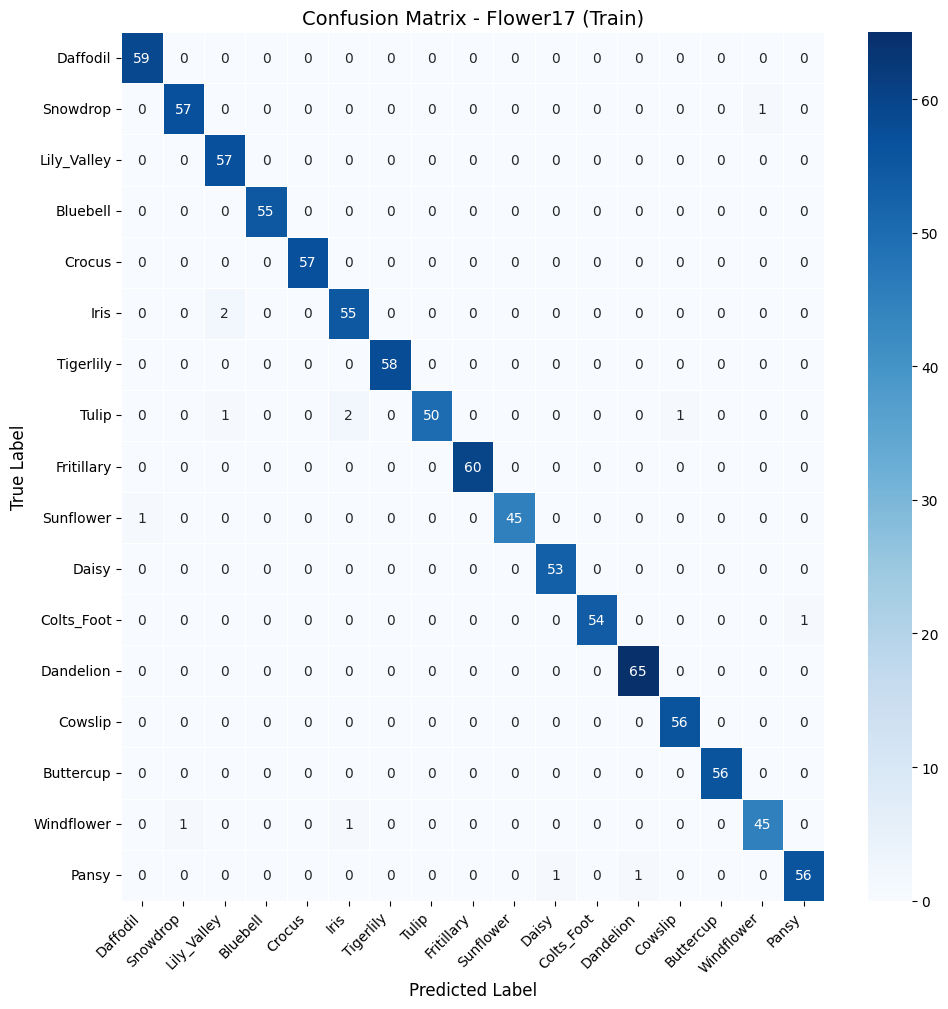


====== Flower17 - Test ======
  Accuracy:            59.34%
  F1-score (Macro):    0.5944
  F1-score (Weighted): 0.5986

  گزارش کامل:
              precision    recall  f1-score   support

    Daffodil     0.7647    0.8667    0.8125        15
    Snowdrop     0.2857    0.2857    0.2857        14
 Lily_Valley     0.3810    0.6154    0.4706        13
    Bluebell     0.3913    0.5000    0.4390        18
      Crocus     0.5333    0.5714    0.5517        14
        Iris     0.4118    0.5833    0.4828        12
   Tigerlily     0.6667    0.7143    0.6897        14
       Tulip     0.8000    0.6667    0.7273        18
  Fritillary     0.8462    0.6875    0.7586        16
   Sunflower     0.9286    0.5652    0.7027        23
       Daisy     0.6154    0.4444    0.5161        18
  Colts_Foot     0.7692    0.6250    0.6897        16
   Dandelion     0.3077    0.6667    0.4211        12
     Cowslip     1.0000    0.8824    0.9375        17
   Buttercup     0.7222    0.8125    0.7647        16

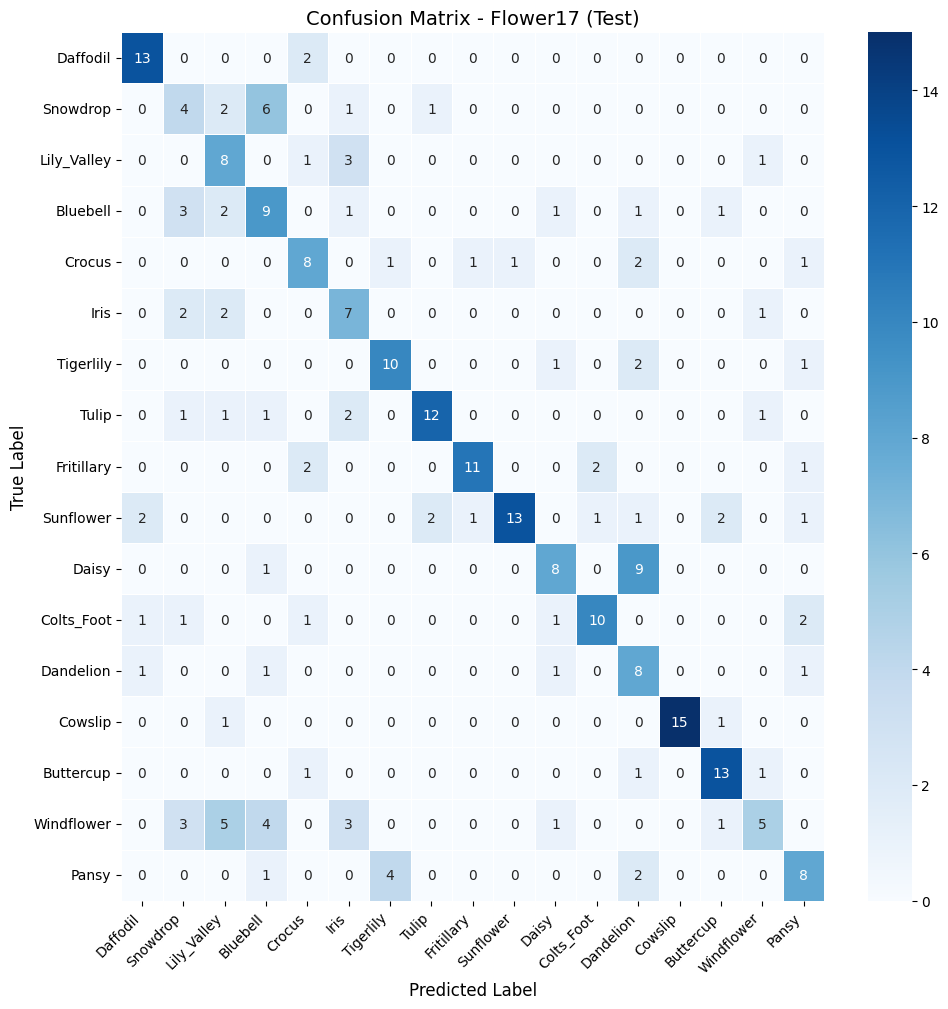

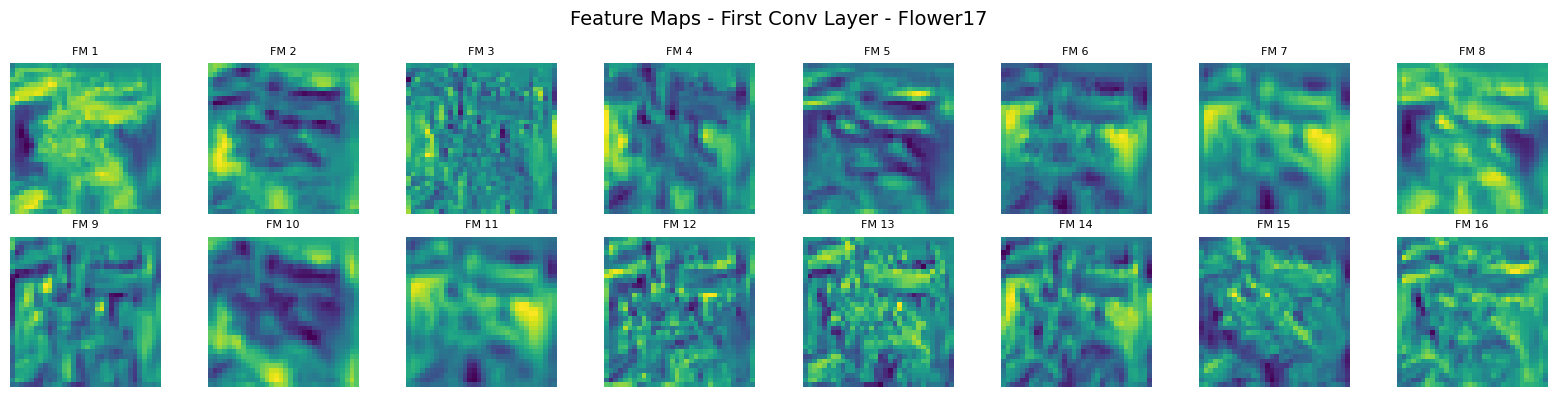

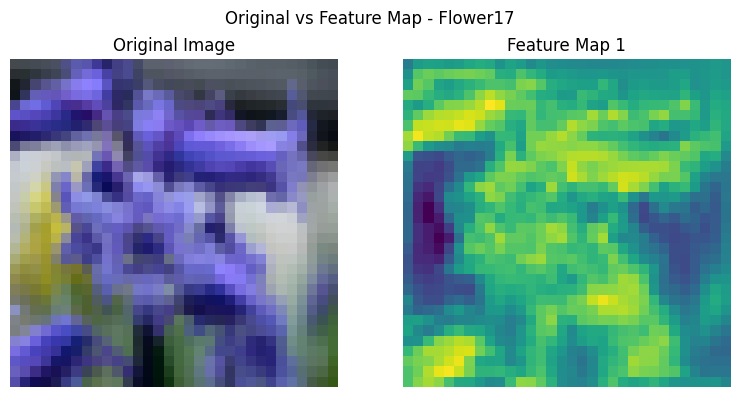

✓ Flower17 model saved → best_model_flower17.pth
✓ Loaded model — saved test acc: 59.34%

     Results CNN with PyTorch
  Fashion-MNIST  |  Accuracy: 92.82%  |  F1-score: 0.9276
  CIFAR-10       |  Accuracy: 75.94%  |  F1-score: 0.7582
  Flower17       |  Accuracy: 59.34%  |  F1-score: 0.5944


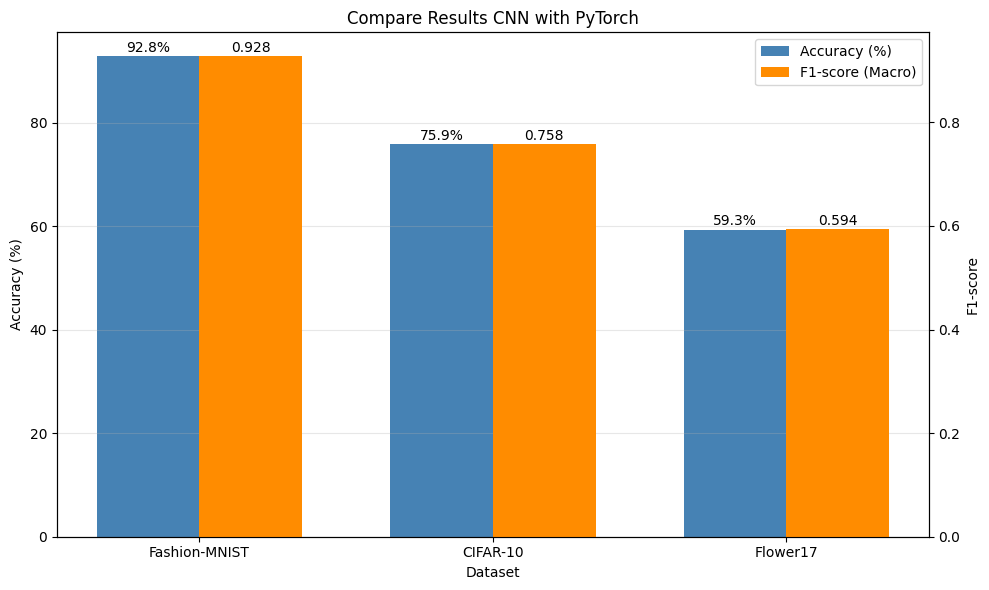


Finished with ready libraries 


In [4]:
#----------------------------------------------------KASRA ATTAR KASHANI ----------------------------
#---------------------------------------------------Deep Learning - HW3 -------------------------------------
#--------------------------------------------------- TASK 2 -------------------------------------------------
#-------------FashionMnist & Cifar & Flower-----USING READY LIBRARIES -------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)
import seaborn as sns
import os
import struct
import gzip
import warnings
warnings.filterwarnings('ignore')

# ======================================
#  GPU DEVICE SETUP
# ======================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')


HYPERPARAMS = {
    'learning_rate': 0.001,
    'batch_size': 64,
    'num_epochs': 10,         
    'dropout_rate': 0.5,
    'conv1_filters': 32,
    'conv2_filters': 64,
    'kernel_size': 3,
    'fc1_units': 256,
    'optimizer': 'Adam',
    'activation': 'ReLU',
    'train_ratio': 0.70,
    'val_ratio': 0.10,
    'test_ratio': 0.20,
    'random_seed': 42
}

torch.manual_seed(HYPERPARAMS['random_seed'])
np.random.seed(HYPERPARAMS['random_seed'])

# Windows: num_workers>0 can cause issues → use 0
NUM_WORKERS = 0

print('هایپرپارامترها:')
for k, v in HYPERPARAMS.items():
    print(f'  {k}: {v}')

# ======================================
#  CNN
# ======================================

class CNN_PyTorch(nn.Module):
    def __init__(self, input_channels, num_classes, input_size, hp):
        super(CNN_PyTorch, self).__init__()

        self.input_size = input_size
        self.hp = hp

        # ---- لایه کانولوشن ۱ ----
        self.conv1 = nn.Conv2d(
            in_channels=input_channels,
            out_channels=hp['conv1_filters'],
            kernel_size=hp['kernel_size'],
            padding=1
        )
        self.bn1 = nn.BatchNorm2d(hp['conv1_filters'])
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ---- لایه کانولوشن ۲ ----
        self.conv2 = nn.Conv2d(
            in_channels=hp['conv1_filters'],
            out_channels=hp['conv2_filters'],
            kernel_size=hp['kernel_size'],
            padding=1
        )
        self.bn2 = nn.BatchNorm2d(hp['conv2_filters'])
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        conv_out_size = (input_size // 4) * (input_size // 4) * hp['conv2_filters']

        # ---- لایه‌های Fully Connected ----
        self.dropout = nn.Dropout(p=hp['dropout_rate'])
        self.fc1 = nn.Linear(conv_out_size, hp['fc1_units'])
        self.bn_fc = nn.BatchNorm1d(hp['fc1_units'])
        self.fc2 = nn.Linear(hp['fc1_units'], num_classes)

        self.feature_maps_conv1 = None

    def forward(self, x):
        x = self.conv1(x)
        self.feature_maps_conv1 = x.detach()
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)

        x = self.dropout(x)
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

print('معماری CNN تعریف شد.')

# ======================================
#  CNN برای Flower17 (input_size=32 - یکسان با from-scratch)
# ======================================

class CNN_PyTorch_Flower(nn.Module):
    def __init__(self, input_channels, num_classes, hp):
        super().__init__()

        self.conv1 = nn.Conv2d(input_channels, hp['conv1_filters'], hp['kernel_size'], padding=1)
        self.bn1   = nn.BatchNorm2d(hp['conv1_filters'])
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(hp['conv1_filters'], hp['conv2_filters'], hp['kernel_size'], padding=1)
        self.bn2   = nn.BatchNorm2d(hp['conv2_filters'])
        self.pool2 = nn.MaxPool2d(2, 2)

        # 32 -> 16 -> 8  (یکسان با from-scratch که SIZE=32 استفاده کرد)
        conv_out = (32 // 4) * (32 // 4) * hp['conv2_filters']

        self.dropout = nn.Dropout(hp['dropout_rate'])
        self.fc1 = nn.Linear(conv_out, hp['fc1_units'])
        self.bn_fc = nn.BatchNorm1d(hp['fc1_units'])
        self.fc2 = nn.Linear(hp['fc1_units'], num_classes)

        self.feature_maps_conv1 = None

    def forward(self, x):
        x = self.conv1(x)
        self.feature_maps_conv1 = x.detach()
        x = F.relu(self.bn1(x))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.dropout(x)
        return self.fc2(x)

print('معماری CNN_Flower تعریف شد.')

# ======================================
#  توابع کمکی
# ======================================

def split_dataset(dataset, hp):
    total = len(dataset)
    train_size = int(hp['train_ratio'] * total)
    val_size   = int(hp['val_ratio']   * total)
    test_size  = total - train_size - val_size

    generator = torch.Generator().manual_seed(hp['random_seed'])
    train_ds, val_ds, test_ds = random_split(
        dataset, [train_size, val_size, test_size], generator=generator
    )

    print(f'  آموزش: {len(train_ds)} | اعتبارسنجی: {len(val_ds)} | آزمون: {len(test_ds)}')
    return train_ds, val_ds, test_ds


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += images.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def plot_training_curves(history, dataset_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   'r-s', markersize=4, label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{dataset_name} - Loss Curves')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Train Acc')
    ax2.plot(epochs, [a*100 for a in history['val_acc']],   'r-s', markersize=4, label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{dataset_name} - Accuracy Curves')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle(f'PyTorch CNN - {dataset_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'pytorch_{dataset_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, dataset_name, split_name='Test'):
    cm = confusion_matrix(y_true, y_pred)
    fig_size = max(8, len(class_names) * 0.6)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'Confusion Matrix - {dataset_name} ({split_name})', fontsize=14)
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'pytorch_{dataset_name}_cm_{split_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


def print_metrics(y_true, y_pred, class_names, dataset_name, split_name='Test'):
    acc        = accuracy_score(y_true, y_pred)
    f1_macro   = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    print(f'\n====== {dataset_name} - {split_name} ======')
    print(f'  Accuracy:            {acc*100:.2f}%')
    print(f'  F1-score (Macro):    {f1_macro:.4f}')
    print(f'  F1-score (Weighted): {f1_weighted:.4f}')
    print('\n  گزارش کامل:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return acc, f1_macro, f1_weighted


def visualize_feature_maps(model, sample_image, dataset_name):
    model.eval()
    with torch.no_grad():
        img_tensor = sample_image.unsqueeze(0).to(device)
        _ = model(img_tensor)

    fmaps = model.feature_maps_conv1[0].cpu().numpy()
    num_maps = min(16, fmaps.shape[0])

    cols = 8
    rows = (num_maps + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    if rows == 1:
        axes = [axes]

    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            ax = axes[i][j]
            if idx < num_maps:
                ax.imshow(fmaps[idx], cmap='viridis')
                ax.set_title(f'FM {idx+1}', fontsize=8)
            ax.axis('off')

    plt.suptitle(f'Feature Maps - First Conv Layer - {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'pytorch_{dataset_name}_feature_maps.png', dpi=150, bbox_inches='tight')
    plt.show()

    # مقایسه تصویر اصلی و اولین feature map
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    img_np = sample_image.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    if img_np.shape[2] == 1:
        axes[0].imshow(img_np[:, :, 0], cmap='gray')
    else:
        axes[0].imshow(img_np)
    axes[0].set_title('Original Image'); axes[0].axis('off')

    axes[1].imshow(fmaps[0], cmap='viridis')
    axes[1].set_title('Feature Map 1'); axes[1].axis('off')

    plt.suptitle(f'Original vs Feature Map - {dataset_name}')
    plt.tight_layout()
    plt.savefig(f'pytorch_{dataset_name}_fm_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


def train_full_pipeline(model, train_loader, val_loader, test_loader, class_names,
                        dataset_name, hp, sample_image):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=hp['learning_rate'])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f'\n--- آموزش {dataset_name} ---')
    for epoch in range(1, hp['num_epochs'] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'  Epoch {epoch:02d}/{hp["num_epochs"]} | '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')

    plot_training_curves(history, dataset_name)

    _, _, train_preds, train_labels = evaluate(model, train_loader, criterion)
    print_metrics(train_labels, train_preds, class_names, dataset_name, 'Train')
    plot_confusion_matrix(train_labels, train_preds, class_names, dataset_name, 'Train')

    _, _, test_preds, test_labels = evaluate(model, test_loader, criterion)
    acc, f1_mac, f1_wt = print_metrics(test_labels, test_preds, class_names, dataset_name, 'Test')
    plot_confusion_matrix(test_labels, test_preds, class_names, dataset_name, 'Test')

    visualize_feature_maps(model, sample_image, dataset_name)

    return model, history, acc, f1_mac


print('توابع کمکی تعریف شدند.')

# ==================================
#  Fashion-MNIST  (از local بخون)
# ==================================
# کد from-scratch این پوشه رو ساخته:
#   ./data/FashionMNIST/raw/  (فایل‌های .gz ubyte)
# torchvision با download=False از همون پوشه می‌خونه

FM_CLASSES = [
    'T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]

fm_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),    # همان 28x28 کد from-scratch
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print('بارگذاری Fashion-MNIST از local...')
fm_train_full = datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=fm_transform
)
fm_test_full = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=fm_transform
)
fm_all = torch.utils.data.ConcatDataset([fm_train_full, fm_test_full])
print(f'Fashion-MNIST - تعداد کل: {len(fm_all)}')

fm_train, fm_val, fm_test = split_dataset(fm_all, HYPERPARAMS)

fm_train_loader = DataLoader(fm_train, batch_size=HYPERPARAMS['batch_size'],
                             shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
fm_val_loader   = DataLoader(fm_val,   batch_size=HYPERPARAMS['batch_size'],
                             shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
fm_test_loader  = DataLoader(fm_test,  batch_size=HYPERPARAMS['batch_size'],
                             shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

fm_sample_img, _ = fm_train_full[0]

# نمایش نمونه تصاویر
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img, label = fm_train_full[i]
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(FM_CLASSES[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images - Fashion-MNIST', fontsize=13)
plt.tight_layout(); plt.show()

print('Fashion-MNIST آماده شد.')

# ---- ساخت و آموزش مدل Fashion-MNIST ----
fm_model = CNN_PyTorch(
    input_channels=1,
    num_classes=10,
    input_size=28,   # یکسان با from-scratch (28x28)
    hp=HYPERPARAMS
)

print('معماری مدل Fashion-MNIST:')
print(fm_model)

# ==========================================================
#  ترسیم گراف شبکه (Network Graph) با torchviz + fallback
# ==========================================================
def draw_network_graph(model, input_shape, dataset_name):
    """
    شکل گرافیکی معماری شبکه را با torchviz رسم می‌کند.
    اگر torchviz نصب نباشد، یک نمای جعبه‌ای ساده با matplotlib می‌سازد.
    """
    model.eval()
    try:
        from torchviz import make_dot
        x = torch.randn(1, *input_shape).to(device)
        y = model(x)
        dot = make_dot(y, params=dict(model.named_parameters()),
                       show_attrs=False, show_saved=False)
        dot.attr(rankdir='TB', size='12,16')
        out_path = f'network_graph_{dataset_name}'
        dot.render(out_path, format='png', cleanup=True)
        print(f'✓ Network graph saved to {out_path}.png')
        # نمایش در نوت‌بوک
        from PIL import Image as PILImage
        img = PILImage.open(out_path + '.png')
        plt.figure(figsize=(10, 14))
        plt.imshow(img); plt.axis('off')
        plt.title(f'Network Architecture Graph - {dataset_name}')
        plt.tight_layout(); plt.show()
    except ImportError:
        # ---- Fallback: نمودار جعبه‌ای ساده با matplotlib ----
        layers = []
        for name, module in model.named_children():
            cls = module.__class__.__name__
            params = sum(p.numel() for p in module.parameters())
            layers.append((name, cls, params))

        fig, ax = plt.subplots(figsize=(9, 1.0 * len(layers) + 1))
        for i, (name, cls, p) in enumerate(layers):
            y = len(layers) - i
            ax.add_patch(plt.Rectangle((0.1, y-0.35), 0.8, 0.7,
                                       fc='lightsteelblue', ec='navy'))
            ax.text(0.5, y, f'{name}: {cls}\n({p:,} params)',
                    ha='center', va='center', fontsize=9)
            if i < len(layers) - 1:
                ax.annotate('', xy=(0.5, y-0.4), xytext=(0.5, y-0.6),
                            arrowprops=dict(arrowstyle='->', color='navy'))
        ax.set_xlim(0, 1); ax.set_ylim(0, len(layers) + 0.5)
        ax.axis('off')
        ax.set_title(f'Network Architecture - {dataset_name}', fontsize=13)
        plt.tight_layout()
        plt.savefig(f'network_graph_{dataset_name}.png', dpi=150, bbox_inches='tight')
        plt.show()

# قبل از اجرای آموزش، گراف رو رسم کن
draw_network_graph(fm_model,    input_shape=(1, 28, 28), dataset_name='Fashion-MNIST')


total_params = sum(p.numel() for p in fm_model.parameters())
print(f'\nتعداد کل پارامترها: {total_params:,}')

fm_model, fm_history, fm_acc, fm_f1 = train_full_pipeline(
    fm_model, fm_train_loader, fm_val_loader, fm_test_loader,
    FM_CLASSES, 'Fashion-MNIST', HYPERPARAMS, fm_sample_img
)

# ---- ذخیره مدل Fashion-MNIST ----
checkpoint = {
    'model_state_dict': fm_model.state_dict(),
    'hyperparams':      HYPERPARAMS,
    'test_acc':         fm_acc,
    'test_f1':          fm_f1,
    'class_names':      FM_CLASSES,
}
torch.save(checkpoint, 'best_model_fashion_mnist.pth')
print('✓ Fashion-MNIST model saved → best_model_fashion_mnist.pth')

# ---- بارگذاری مجدد برای اعتبارسنجی ----
loaded = torch.load('best_model_fashion_mnist.pth', map_location=device)
fm_model_loaded = CNN_PyTorch(input_channels=1, num_classes=10,
                              input_size=28, hp=loaded['hyperparams']).to(device)
fm_model_loaded.load_state_dict(loaded['model_state_dict'])
fm_model_loaded.eval()
print(f'✓ Loaded model — saved test acc: {loaded["test_acc"]*100:.2f}%')


# ==================================
#  CIFAR-10  (از local بخون)
# ==================================
# کد from-scratch این پوشه رو ساخته:
#   ./data/cifar-10-batches-py/

CIFAR_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

cifar_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

print('بارگذاری CIFAR-10 از local...')
cifar_train_full = datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=cifar_transform
)
cifar_test_full = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=cifar_transform
)
cifar_all = torch.utils.data.ConcatDataset([cifar_train_full, cifar_test_full])
print(f'CIFAR-10 - تعداد کل: {len(cifar_all)}')

cifar_train, cifar_val, cifar_test = split_dataset(cifar_all, HYPERPARAMS)

cifar_train_loader = DataLoader(cifar_train, batch_size=HYPERPARAMS['batch_size'],
                                shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
cifar_val_loader   = DataLoader(cifar_val,   batch_size=HYPERPARAMS['batch_size'],
                                shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
cifar_test_loader  = DataLoader(cifar_test,  batch_size=HYPERPARAMS['batch_size'],
                                shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

cifar_sample_img, _ = cifar_train_full[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img, label = cifar_train_full[i]
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    ax.imshow(img_np)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images - CIFAR-10', fontsize=13)
plt.tight_layout(); plt.show()


print('CIFAR-10 آماده شد.')



# ---- ساخت و آموزش مدل CIFAR-10 ----
cifar_model = CNN_PyTorch(
    input_channels=3,
    num_classes=10,
    input_size=32,
    hp=HYPERPARAMS
)


total_params = sum(p.numel() for p in cifar_model.parameters())
print(f'تعداد کل پارامترها: {total_params:,}')

draw_network_graph(cifar_model, input_shape=(3, 32, 32), dataset_name='CIFAR-10')

cifar_model, cifar_history, cifar_acc, cifar_f1 = train_full_pipeline(
    cifar_model, cifar_train_loader, cifar_val_loader, cifar_test_loader,
    CIFAR_CLASSES, 'CIFAR-10', HYPERPARAMS, cifar_sample_img
)

# ---- ذخیره مدل CIFAR-10 ----
checkpoint = {
    'model_state_dict': cifar_model.state_dict(),
    'hyperparams':      HYPERPARAMS,
    'test_acc':         cifar_acc,
    'test_f1':          cifar_f1,
    'class_names':      CIFAR_CLASSES,
}
torch.save(checkpoint, 'best_model_cifar10.pth')
print('✓ CIFAR-10 model saved → best_model_cifar10.pth')

loaded = torch.load('best_model_cifar10.pth', map_location=device)
cifar_model_loaded = CNN_PyTorch(input_channels=3, num_classes=10,
                                 input_size=32, hp=loaded['hyperparams']).to(device)
cifar_model_loaded.load_state_dict(loaded['model_state_dict'])
cifar_model_loaded.eval()
print(f'✓ Loaded model — saved test acc: {loaded["test_acc"]*100:.2f}%')


# ==================================
#  Flower17  (از local بخون)
# ==================================
# کد from-scratch این پوشه رو ساخت:
#   ./data/flowers17_organized/<ClassName>/
# هر کلاس 80 تصویر - ریسایز به 32x32

FLOWER_CLASSES = [
    'Daffodil', 'Snowdrop', 'Lily_Valley', 'Bluebell', 'Crocus',
    'Iris', 'Tigerlily', 'Tulip', 'Fritillary', 'Sunflower',
    'Daisy', 'Colts_Foot', 'Dandelion', 'Cowslip', 'Buttercup',
    'Windflower', 'Pansy'
]

organized_dir = './data/flowers17_organized'

# تنها transform - بدون augmentation تا یکسان با from-scratch باشه
flower_transform = transforms.Compose([
    transforms.Resize((32, 32)),     # یکسان با SIZE=32 در from-scratch
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print('بارگذاری Flower17 از local...')
flower_all = datasets.ImageFolder(root=organized_dir, transform=flower_transform)
print(f'Flower17 - تعداد کل: {len(flower_all)}')
print(f'کلاس‌های پیدا شده: {flower_all.classes}')

flower_train, flower_val, flower_test = split_dataset(flower_all, HYPERPARAMS)

flower_train_loader = DataLoader(flower_train, batch_size=HYPERPARAMS['batch_size'],
                                 shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
flower_val_loader   = DataLoader(flower_val,   batch_size=HYPERPARAMS['batch_size'],
                                 shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
flower_test_loader  = DataLoader(flower_test,  batch_size=HYPERPARAMS['batch_size'],
                                 shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

flower_sample_img, _ = flower_all[0]

# نمایش نمونه
from PIL import Image
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for i, ax in enumerate(axes.flatten()):
    if i >= len(FLOWER_CLASSES):
        ax.axis('off')
        continue
    cls_dir  = os.path.join(organized_dir, FLOWER_CLASSES[i])
    img_name = sorted(os.listdir(cls_dir))[0]
    img = Image.open(os.path.join(cls_dir, img_name))
    ax.imshow(img)
    ax.set_title(FLOWER_CLASSES[i], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Images - Flower17', fontsize=13)
plt.tight_layout(); plt.show()

print('Flower17 آماده شد.')

# ---- ساخت و آموزش مدل Flower17 ----
flower_model = CNN_PyTorch_Flower(
    input_channels=3,
    num_classes=17,
    hp=HYPERPARAMS
)

total_params = sum(p.numel() for p in flower_model.parameters())
print(f'تعداد کل پارامترها (Flower17): {total_params:,}')

draw_network_graph(flower_model, input_shape=(3, 32, 32), dataset_name='Flower17')

flower_model, flower_history, flower_acc, flower_f1 = train_full_pipeline(
    flower_model, flower_train_loader, flower_val_loader, flower_test_loader,
    FLOWER_CLASSES, 'Flower17', HYPERPARAMS, flower_sample_img
)

# ---- ذخیره مدل Flower17 ----
checkpoint = {
    'model_state_dict': flower_model.state_dict(),
    'hyperparams':      HYPERPARAMS,
    'test_acc':         flower_acc,
    'test_f1':          flower_f1,
    'class_names':      FLOWER_CLASSES,
}
torch.save(checkpoint, 'best_model_flower17.pth')
print('✓ Flower17 model saved → best_model_flower17.pth')

loaded = torch.load('best_model_flower17.pth', map_location=device)
flower_model_loaded = CNN_PyTorch_Flower(input_channels=3, num_classes=17,
                                         hp=loaded['hyperparams']).to(device)
flower_model_loaded.load_state_dict(loaded['model_state_dict'])
flower_model_loaded.eval()
print(f'✓ Loaded model — saved test acc: {loaded["test_acc"]*100:.2f}%')


# ==================================
#  جمع‌بندی نتایج
# ==================================
print('\n' + '='*60)
print('     Results CNN with PyTorch')
print('='*60)
print(f'  Fashion-MNIST  |  Accuracy: {fm_acc*100:.2f}%  |  F1-score: {fm_f1:.4f}')
print(f'  CIFAR-10       |  Accuracy: {cifar_acc*100:.2f}%  |  F1-score: {cifar_f1:.4f}')
print(f'  Flower17       |  Accuracy: {flower_acc*100:.2f}%  |  F1-score: {flower_f1:.4f}')
print('='*60)

# نمودار مقایسه
datasets_names = ['Fashion-MNIST', 'CIFAR-10', 'Flower17']
accuracies = [fm_acc*100, cifar_acc*100, flower_acc*100]
f1_scores  = [fm_f1, cifar_f1, flower_f1]

x = np.arange(len(datasets_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)', color='steelblue')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, f1_scores, width, label='F1-score (Macro)', color='darkorange')

ax.set_xlabel('Dataset')
ax.set_ylabel('Accuracy (%)')
ax2.set_ylabel('F1-score')
ax.set_title('Compare Results CNN with PyTorch')
ax.set_xticks(x); ax.set_xticklabels(datasets_names)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    ax2.annotate(f'{bar.get_height():.3f}',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pytorch_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFinished with ready libraries ')


>>> Sensitivity 1/8 : Learning Rate


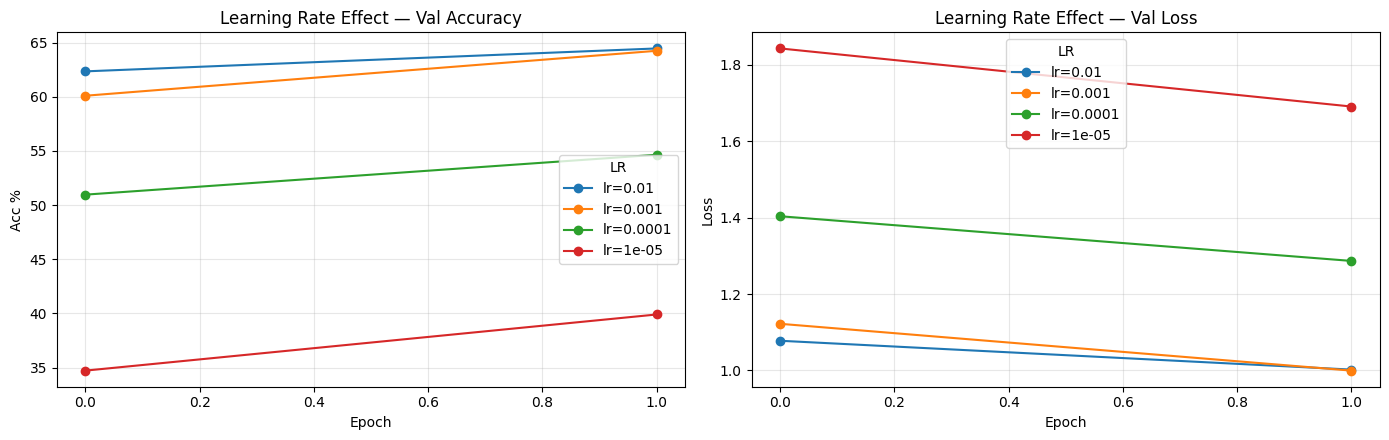

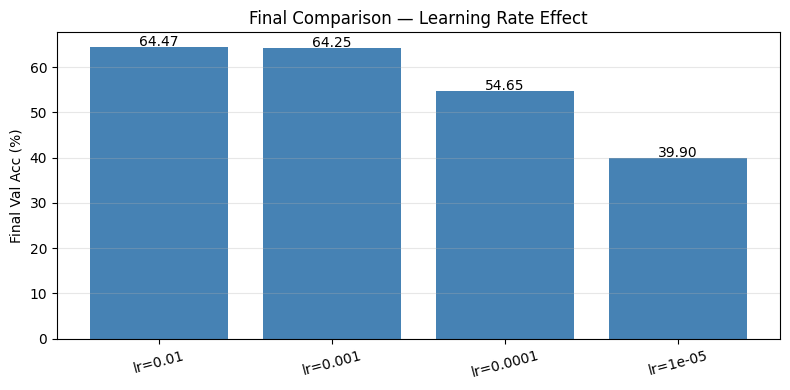


>>> Sensitivity 2/8 : Batch Size


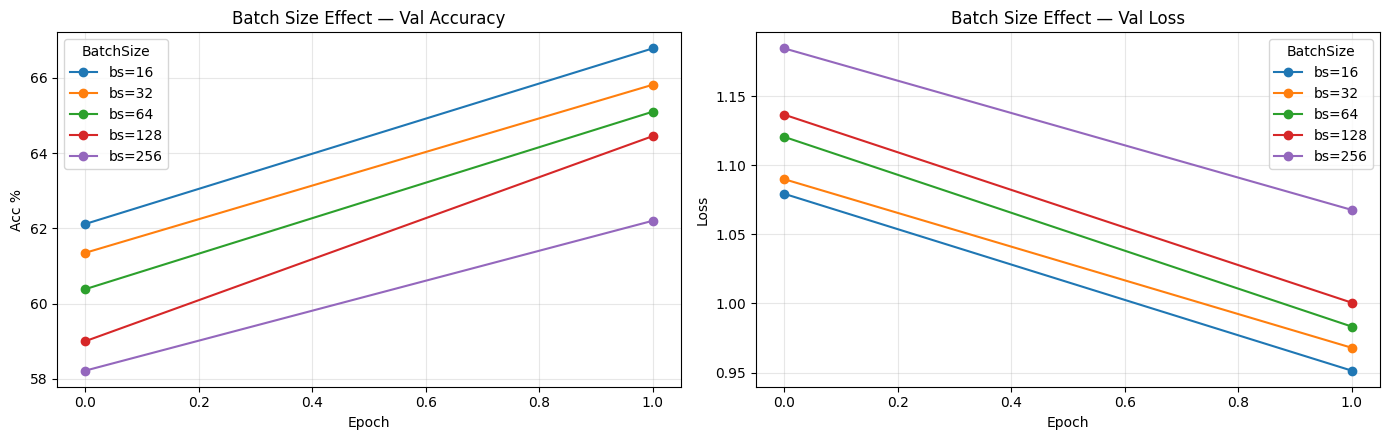

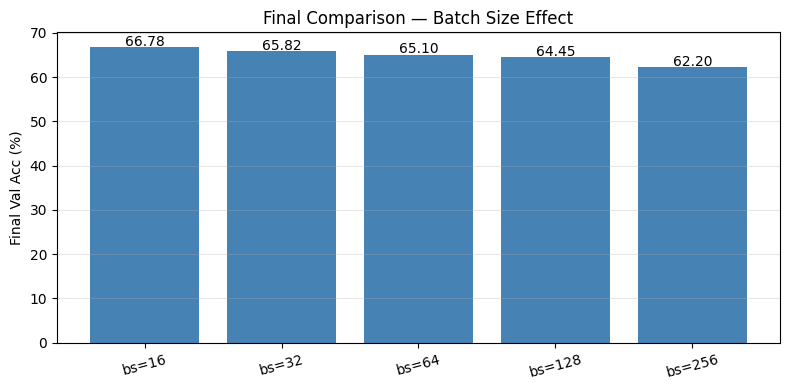


>>> Sensitivity 3/8 : Activation Function


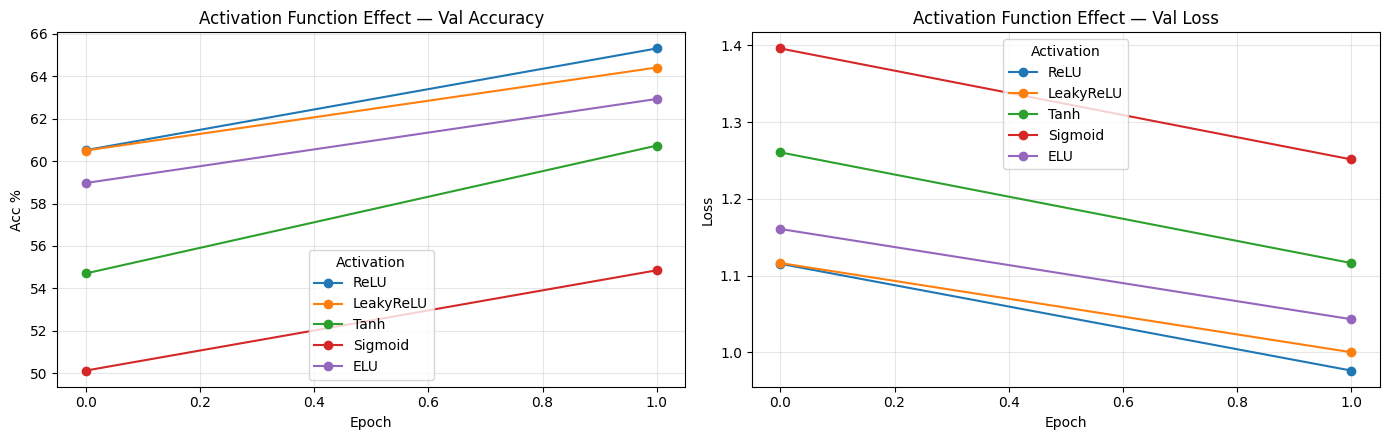

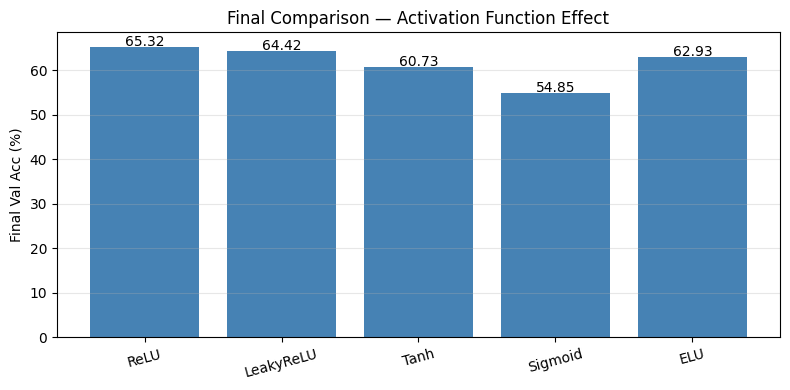


>>> Sensitivity 4/8 : Optimizer


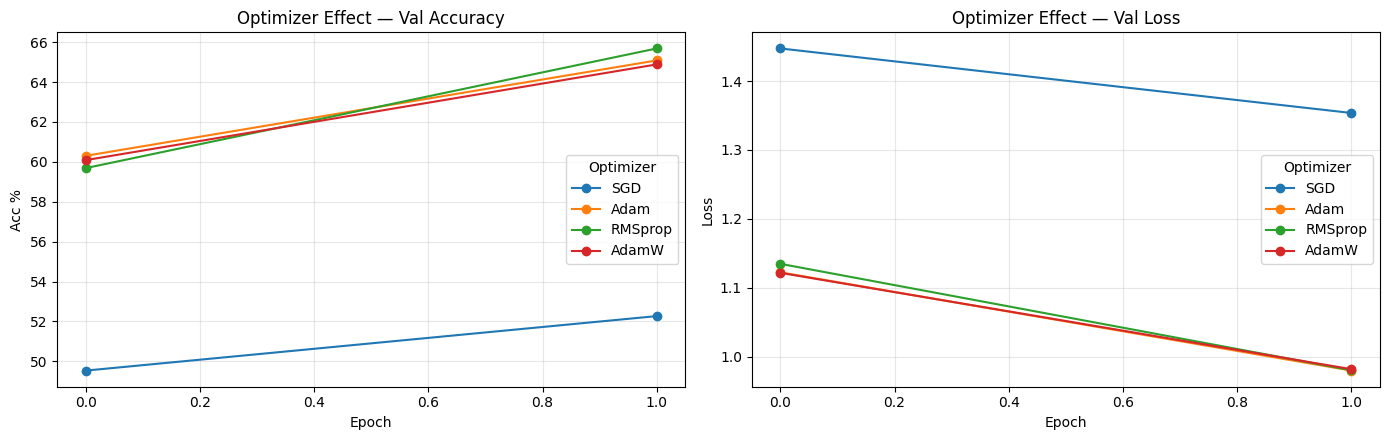

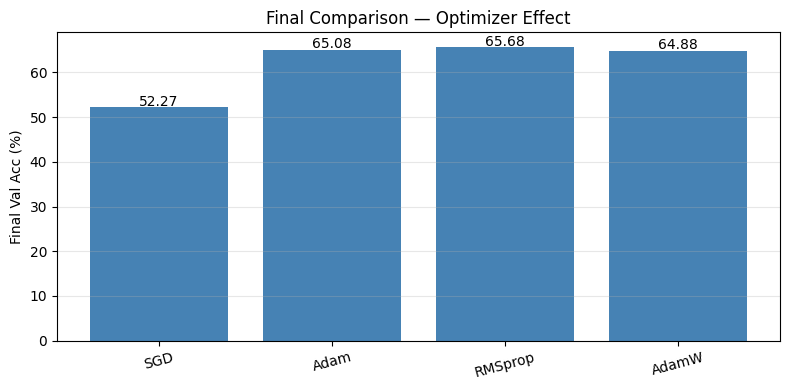


>>> Sensitivity 5/8 : L2 Regularization


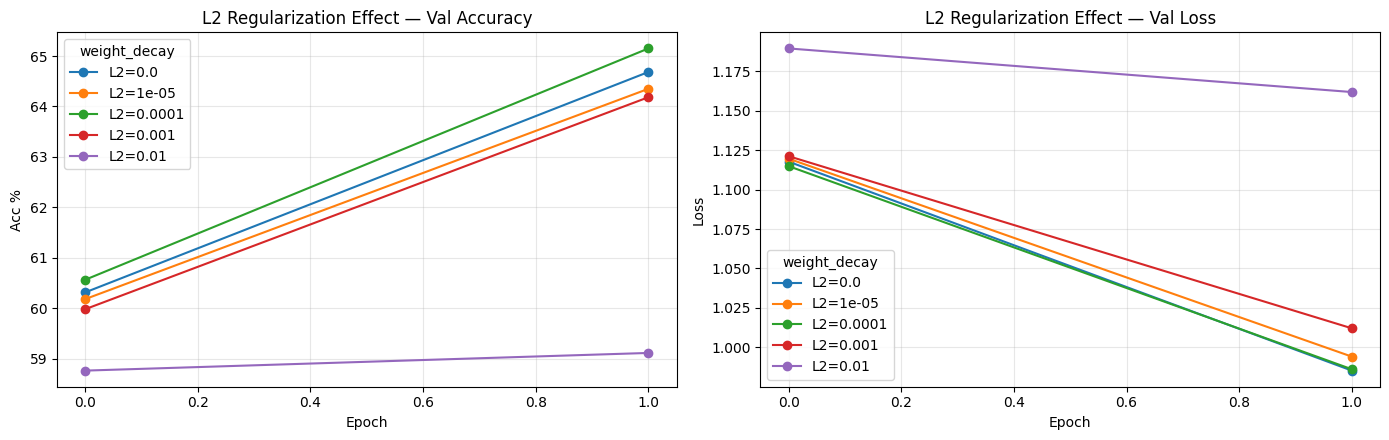

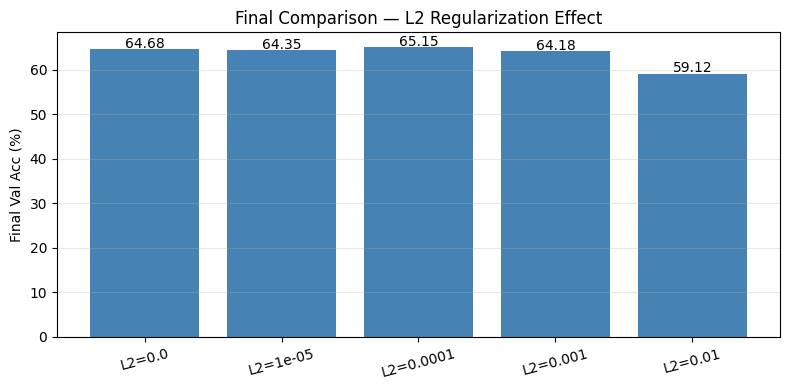


>>> Sensitivity 6/8 : L1 Regularization


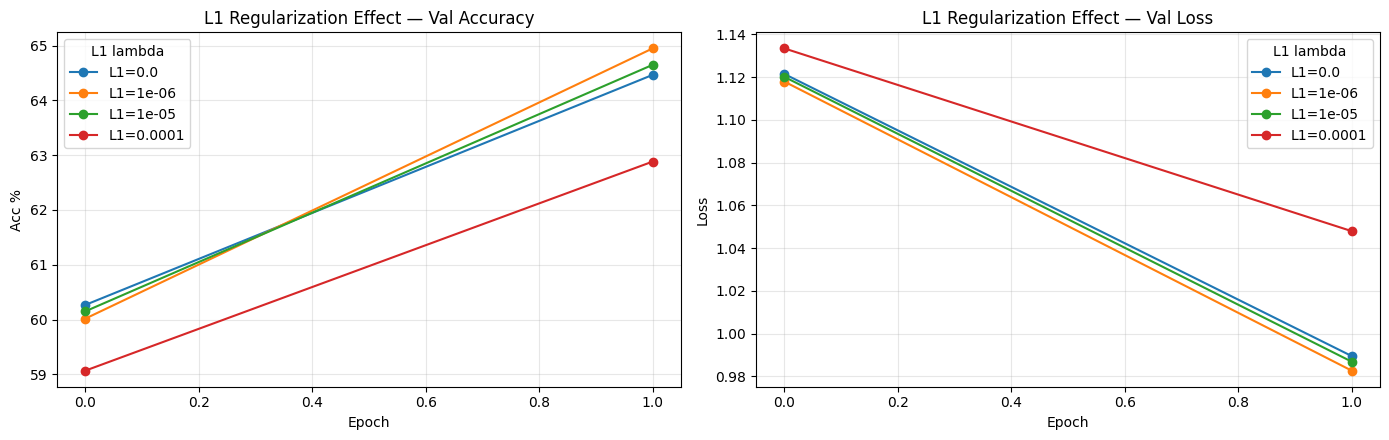

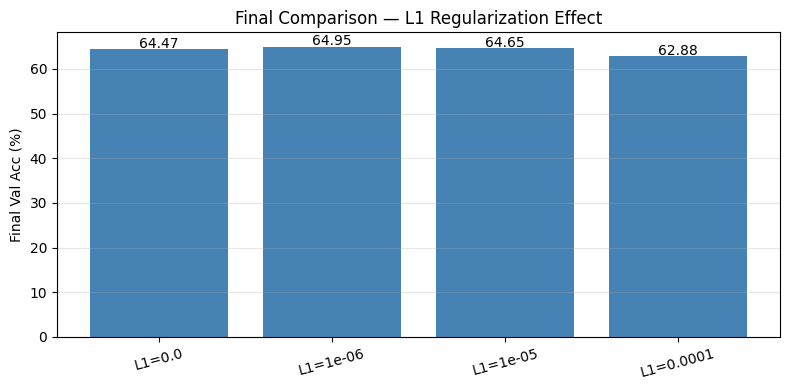


>>> Sensitivity 7/8 : Dropout Rate


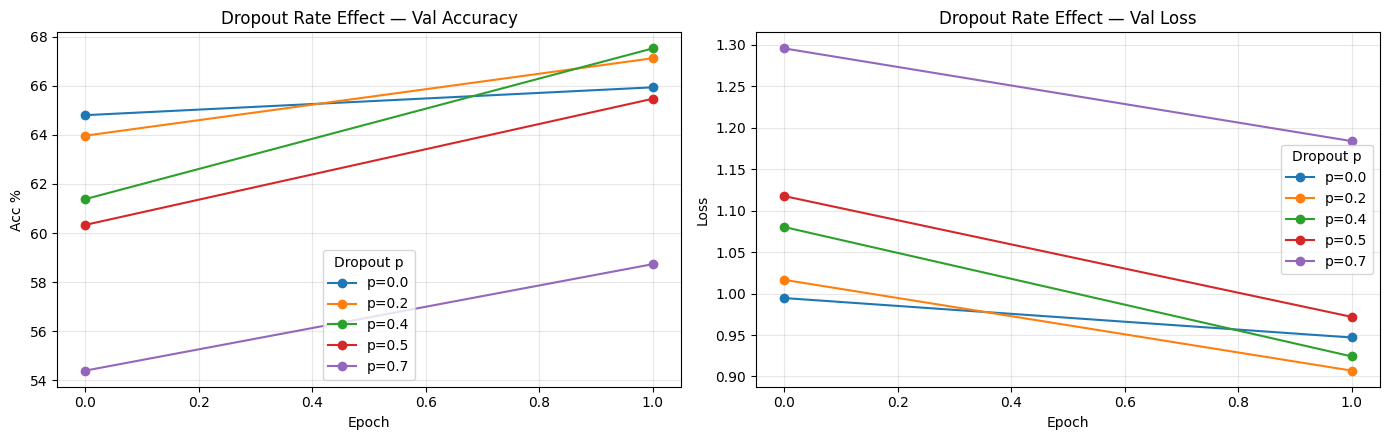

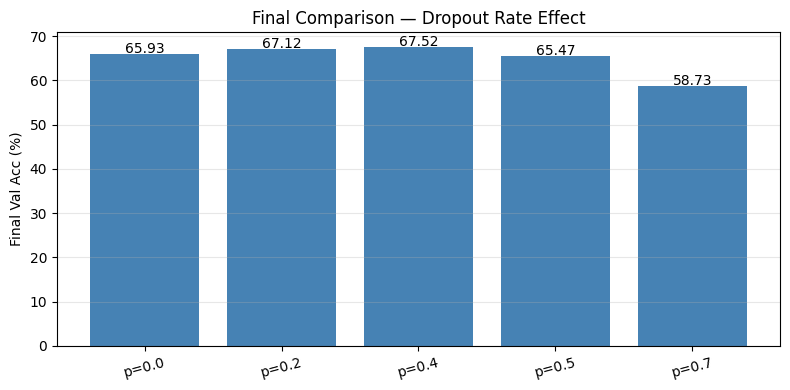


>>> Sensitivity 8/8 : Weight Initialization


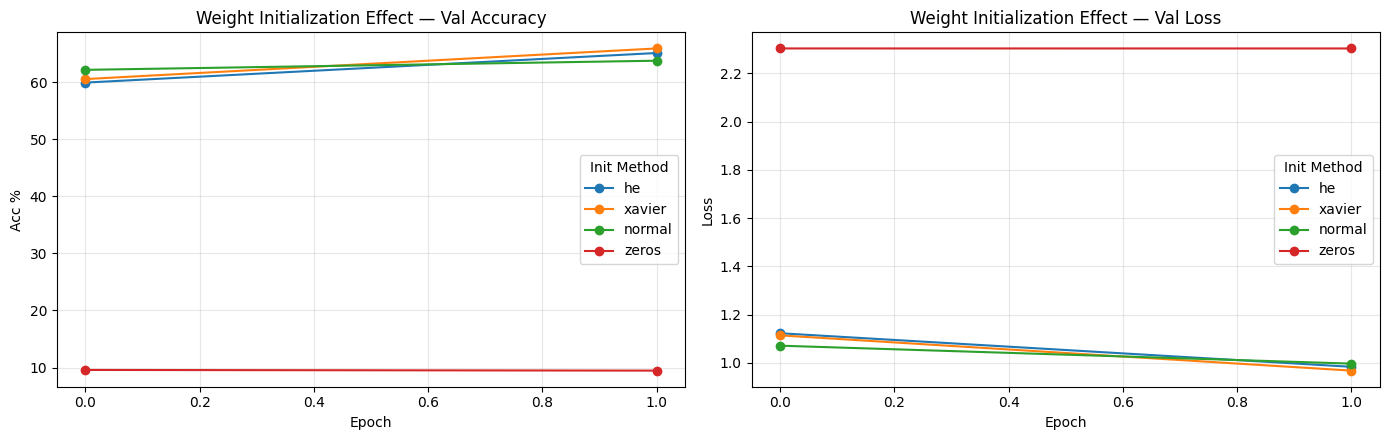

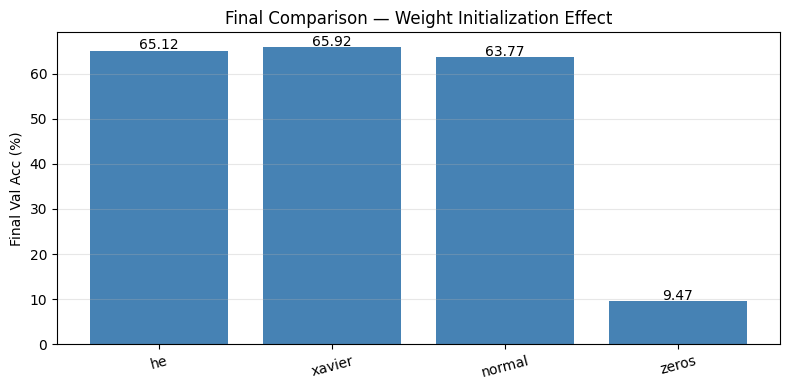


   بهترین مقدار هایپرپارامترها (بر اساس val acc):
  Learning Rate    : lr=0.01
  Batch Size       : bs=16
  Activation       : ReLU
  Optimizer        : RMSprop
  L2 weight_decay  : L2=0.0001
  Dropout          : p=0.4
  Init Method      : xavier


In [10]:
# ============================================================
#  HYPERPARAMETER SENSITIVITY ANALYSIS  (روی CIFAR-10)
# ============================================================
#SEED = HYPERPARAMS['random_seed']  # = 42
SEED = 42
SENS_EPOCHS = 2   # برای سرعت
SENS_DATASET = 'CIFAR-10'

def quick_train(model, train_loader, val_loader, epochs, lr, optimizer_name,
                weight_decay=0.0, l1_lambda=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == 'Adam':
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        opt = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    hist = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    for ep in range(epochs):
        model.train()
        correct, total, run_loss = 0, 0, 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            # L1 regularization دستی
            if l1_lambda > 0:
                l1 = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1
            loss.backward(); opt.step()
            run_loss += loss.item() * x.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            total   += x.size(0)
        hist['train_acc'].append(correct/total)
        hist['train_loss'].append(run_loss/total)

        # val
        model.eval(); vc, vt, vl = 0, 0, 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                vl += criterion(out, y).item() * x.size(0)
                vc += out.argmax(1).eq(y).sum().item()
                vt += x.size(0)
        hist['val_acc'].append(vc/vt)
        hist['val_loss'].append(vl/vt)
    return hist


def build_cnn(activation='ReLU', dropout=0.5, init_method='he'):
    """نسخه‌ی پارامتری CNN برای آزمایش‌های حساسیت."""
    class _CNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
            self.bn1   = nn.BatchNorm2d(32)
            self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
            self.bn2   = nn.BatchNorm2d(64)
            self.pool  = nn.MaxPool2d(2, 2)
            self.fc1   = nn.Linear(64*8*8, 256)
            self.bn_fc = nn.BatchNorm1d(256)
            self.fc2   = nn.Linear(256, 10)
            self.drop  = nn.Dropout(dropout)
            self.act_name = activation
        def _act(self, x):
            return {'ReLU': F.relu, 'LeakyReLU': F.leaky_relu,
                    'Tanh': torch.tanh, 'Sigmoid': torch.sigmoid,
                    'ELU': F.elu}[self.act_name](x)
        def forward(self, x):
            x = self.pool(self._act(self.bn1(self.conv1(x))))
            x = self.pool(self._act(self.bn2(self.conv2(x))))
            x = x.view(x.size(0), -1)
            x = self.drop(x)
            x = self._act(self.bn_fc(self.fc1(x)))
            x = self.drop(x)
            return self.fc2(x)
    net = _CNN()
    # init weights
    for m in net.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if init_method == 'he':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif init_method == 'xavier':
                nn.init.xavier_normal_(m.weight)
            elif init_method == 'normal':
                nn.init.normal_(m.weight, mean=0, std=0.02)
            elif init_method == 'zeros':
                nn.init.zeros_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return net


def plot_sensitivity(results, title, xlabel):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
    for k, h in results.items():
        ax1.plot([a*100 for a in h['val_acc']], '-o', label=str(k))
        ax2.plot(h['val_loss'], '-o', label=str(k))
    ax1.set_title(f'{title} — Val Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Acc %')
    ax2.set_title(f'{title} — Val Loss');     ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax1.legend(title=xlabel); ax2.legend(title=xlabel)
    ax1.grid(alpha=.3); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'sens_{title.replace(" ","_")}.png', dpi=130); plt.show()
    # bar chart نهایی
    final = {k: h['val_acc'][-1]*100 for k, h in results.items()}
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(final)), list(final.values()), color='steelblue')
    plt.xticks(range(len(final)), [str(k) for k in final.keys()], rotation=15)
    plt.ylabel('Final Val Acc (%)'); plt.title(f'Final Comparison — {title}')
    for i, v in enumerate(final.values()):
        plt.text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=10)
    plt.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()
    return final


# ============= ۱) اثر Learning Rate =============
print('\n>>> Sensitivity 1/8 : Learning Rate')
res_lr = {}
for lr in [1e-2, 1e-3, 1e-4, 1e-5]:
    torch.manual_seed(SEED)
    net = build_cnn()
    res_lr[f'lr={lr}'] = quick_train(net, cifar_train_loader, cifar_val_loader,
                                     SENS_EPOCHS, lr, 'Adam')
plot_sensitivity(res_lr, 'Learning Rate Effect', 'LR')

# ============= ۲) اثر Batch Size =============
print('\n>>> Sensitivity 2/8 : Batch Size')
res_bs = {}
for bs in [16, 32, 64, 128, 256]:
    tl = DataLoader(cifar_train, batch_size=bs, shuffle=True,  num_workers=0)
    vl = DataLoader(cifar_val,   batch_size=bs, shuffle=False, num_workers=0)
    torch.manual_seed(SEED)
    net = build_cnn()
    res_bs[f'bs={bs}'] = quick_train(net, tl, vl, SENS_EPOCHS, 1e-3, 'Adam')
plot_sensitivity(res_bs, 'Batch Size Effect', 'BatchSize')

# ============= ۳) اثر Activation Function =============
print('\n>>> Sensitivity 3/8 : Activation Function')
res_act = {}
for act in ['ReLU', 'LeakyReLU', 'Tanh', 'Sigmoid', 'ELU']:
    torch.manual_seed(SEED)
    net = build_cnn(activation=act)
    res_act[act] = quick_train(net, cifar_train_loader, cifar_val_loader,
                               SENS_EPOCHS, 1e-3, 'Adam')
plot_sensitivity(res_act, 'Activation Function Effect', 'Activation')

# ============= ۴) اثر Optimizer =============
print('\n>>> Sensitivity 4/8 : Optimizer')
res_opt = {}
for opt_name in ['SGD', 'Adam', 'RMSprop', 'AdamW']:
    torch.manual_seed(SEED)
    net = build_cnn()
    res_opt[opt_name] = quick_train(net, cifar_train_loader, cifar_val_loader,
                                    SENS_EPOCHS, 1e-3, opt_name)
plot_sensitivity(res_opt, 'Optimizer Effect', 'Optimizer')

# ============= ۵) اثر L2 Regularization (weight_decay) =============
print('\n>>> Sensitivity 5/8 : L2 Regularization')
res_l2 = {}
for wd in [0.0, 1e-5, 1e-4, 1e-3, 1e-2]:
    torch.manual_seed(SEED)
    net = build_cnn()
    res_l2[f'L2={wd}'] = quick_train(net, cifar_train_loader, cifar_val_loader,
                                     SENS_EPOCHS, 1e-3, 'Adam', weight_decay=wd)
plot_sensitivity(res_l2, 'L2 Regularization Effect', 'weight_decay')

# ============= ۶) اثر L1 Regularization =============
print('\n>>> Sensitivity 6/8 : L1 Regularization')
res_l1 = {}
for l1 in [0.0, 1e-6, 1e-5, 1e-4]:
    torch.manual_seed(SEED)
    net = build_cnn()
    res_l1[f'L1={l1}'] = quick_train(net, cifar_train_loader, cifar_val_loader,
                                     SENS_EPOCHS, 1e-3, 'Adam', l1_lambda=l1)
plot_sensitivity(res_l1, 'L1 Regularization Effect', 'L1 lambda')

# ============= ۷) اثر Dropout =============
print('\n>>> Sensitivity 7/8 : Dropout Rate')
res_dp = {}
for dp in [0.0, 0.2, 0.4, 0.5, 0.7]:
    torch.manual_seed(SEED)
    net = build_cnn(dropout=dp)
    res_dp[f'p={dp}'] = quick_train(net, cifar_train_loader, cifar_val_loader,
                                    SENS_EPOCHS, 1e-3, 'Adam')
plot_sensitivity(res_dp, 'Dropout Rate Effect', 'Dropout p')

# ============= ۸) اثر Weight Initialization =============
print('\n>>> Sensitivity 8/8 : Weight Initialization')
res_init = {}
for init in ['he', 'xavier', 'normal', 'zeros']:
    torch.manual_seed(SEED)
    net = build_cnn(init_method=init)
    res_init[init] = quick_train(net, cifar_train_loader, cifar_val_loader,
                                 SENS_EPOCHS, 1e-3, 'Adam')
plot_sensitivity(res_init, 'Weight Initialization Effect', 'Init Method')

# ============= خلاصه نهایی هایپرپارامترهای بهینه =============
best_lr   = max(res_lr,   key=lambda k: res_lr[k]['val_acc'][-1])
best_bs   = max(res_bs,   key=lambda k: res_bs[k]['val_acc'][-1])
best_act  = max(res_act,  key=lambda k: res_act[k]['val_acc'][-1])
best_opt  = max(res_opt,  key=lambda k: res_opt[k]['val_acc'][-1])
best_l2   = max(res_l2,   key=lambda k: res_l2[k]['val_acc'][-1])
best_dp   = max(res_dp,   key=lambda k: res_dp[k]['val_acc'][-1])
best_init = max(res_init, key=lambda k: res_init[k]['val_acc'][-1])

print('\n' + '='*60)
print('   بهترین مقدار هایپرپارامترها (بر اساس val acc):')
print('='*60)
print(f'  Learning Rate    : {best_lr}')
print(f'  Batch Size       : {best_bs}')
print(f'  Activation       : {best_act}')
print(f'  Optimizer        : {best_opt}')
print(f'  L2 weight_decay  : {best_l2}')
print(f'  Dropout          : {best_dp}')
print(f'  Init Method      : {best_init}')
print('='*60)
